# EDA A — Cohort and Variable Inventory Overview
## Endometriosis & Intrapartum Cesarean Section — Sheba Medical Center

---

## Academic Project Notebook

This notebook is prepared for academic project review and internal research use. Direct
patient identifiers and patient-level tabular records are not intentionally displayed.
Aggregate summaries and diagnostic visualizations are presented for methodological
review. The notebook should not be treated as an unrestricted public-release data
product.

**Cohort status:** the current analysis uses the implemented, clinically confirmed
cohort of N=431. The exclusion of 16 suspected superficial-only endometriosis
records is implemented and was externally confirmed by Sheba on 2026-08-18
(Decision 67 external-confirmation addendum; see Section A4 for the full
before/after accounting).

---

## Section A0 — Overview

This notebook is Part 1 of the exploratory data analysis for the endometriosis and
intrapartum cesarean section study. It presents the processed cohort, the full
variable inventory and classification, and an initial descriptive overview of the
dataset. Deeper predictor-level analysis (associations, correlations, outlier
review) continues in the companion Part 2 notebook. The dataframe is not modified
at any point.

## Section A1 — Setup

In [1]:
# The notebook does not save new outputs by default, reducing the risk of
# unintended project-file changes.
SAVE_AGGREGATED_OUTPUTS = False

# Automated third-party profiling (ydata-profiling, Section A5c) is
# opt-in, default OFF. It must never run, and must never create
# its output directory, unless BOTH this flag AND SAVE_AGGREGATED_OUTPUTS are
# explicitly set True -- see that section for the full allowlist/privacy
# design once enabled.
RUN_AUTOMATED_PROFILING = False

# Share-safe output mode, default
# ON: suppresses small-cell (n<5) counts/percentages in the sections
# reviewed below so this notebook's rendered output is safer to export and
# share as HTML. See eda_shared/share_safe.py.
#
# COVERAGE STATE (per-section audit -- do not read this
# flag as "the whole notebook is fully share-safe" without reading this
# list): A6 (Table 1 binary n_positive/positive_%) and A8 (IQR outlier
# n_flagged/flagged_%) are actively suppressed via share_safe when this flag
# is True. A7's subgroup/missingness report has its own pre-existing,
# equally rigorous n<5 disclosure guard (_SG_MIN_DISCLOSURE_N, predates the
# shared share_safe module -- not migrated, but equivalent in effect). A4's
# cohort-derivation counts include a protected small-cell exclusion (Decision
# 32); the literal count is never hardcoded in this notebook's own source --
# see the DECISION_32_PLACENTA_EXCLUDED_ROWS import in Section A4 -- and the
# rendered before/after cohort-flow display is structured so the count
# cannot be recovered by arithmetic from other displayed values either (see
# Section A4's own comments for the full rationale). Sections outside
# A4/A6/A7/A8 were not part of this audit's scope. Set to False only for
# local, non-shared review.
SHARE_SAFE_MODE = True

print(f"SAVE_AGGREGATED_OUTPUTS = {SAVE_AGGREGATED_OUTPUTS}")
print(f"RUN_AUTOMATED_PROFILING = {RUN_AUTOMATED_PROFILING}")
print(f"SHARE_SAFE_MODE = {SHARE_SAFE_MODE}")
print("  NOTE: SHARE_SAFE_MODE=True suppresses small-cell (n<5) counts/percentages in")
print("  the specific sections documented in this cell's source comment (A6, A8; A7 has")
print("  its own equivalent pre-existing guard). It does NOT make this notebook fully")
print("  share-safe -- point-level plots, exact cohort/subgroup counts elsewhere, and")
print("  numeric ranges are still present. This notebook is prepared for academic")
print("  project review and internal research use, not unrestricted public release --")
print("  see Section A0.")

SAVE_AGGREGATED_OUTPUTS = False
RUN_AUTOMATED_PROFILING = False
SHARE_SAFE_MODE = True
  NOTE: SHARE_SAFE_MODE=True suppresses small-cell (n<5) counts/percentages in
  the specific sections documented in this cell's source comment (A6, A8; A7 has
  its own equivalent pre-existing guard). It does NOT make this notebook fully
  share-safe -- point-level plots, exact cohort/subgroup counts elsewhere, and
  numeric ranges are still present. This notebook is prepared for academic
  project review and internal research use, not unrestricted public release --
  see Section A0.


In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys, os, re, zipfile, warnings

# Use the inline backend so plt.show() embeds a PNG in the notebook output
# instead of silently discarding the figure under a non-interactive backend.
# get_ipython() only exists inside a real Jupyter/IPython kernel -- this is a
# no-op (NameError, caught) when the cell source is exec'd directly by a
# plain-Python test harness, which several tests in this repo do.
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
matplotlib.rcParams["figure.dpi"] = 90
_MUTED = sns.color_palette("muted")
C0, C1 = _MUTED[0], _MUTED[3]

print(f"pandas {pd.__version__} | seaborn {sns.__version__} | Imports OK")

pandas 2.3.3 | seaborn 0.13.2 | Imports OK


In [3]:
# Load approved variable classification CSV directly. No config.py or embedded fallback is used.
IN_COLAB = "google.colab" in sys.modules

# This notebook is local-repository-only: later setup steps load
# structural_missingness_registry.py, share_safe.py, canonical_data_manifest.py,
# and canonical_data_resolver.py directly from the repository filesystem, and
# none of those shared modules has a Colab upload flow. The check therefore
# runs immediately, before any upload prompt, so a Colab user gets one clear
# message up front rather than being asked to upload files that could never
# be used.
if IN_COLAB:
    raise RuntimeError(
        "This notebook is local-repository-only and cannot currently run in "
        "Google Colab: later setup steps load structural_missingness_registry.py, "
        "share_safe.py, canonical_data_manifest.py, and canonical_data_resolver.py "
        "directly from the repository filesystem (analysis/eda/notebook_build/"
        "eda_shared/), which Colab does not have access to. Run this notebook "
        "locally from a clone of the repository instead."
    )

PROJECT_ROOT_OVERRIDE = None
CLASSIFICATION_REL = "outputs/preprocessing/audit/variable_classification_minimal.csv"
PROCESSED_GLOB = "outputs/preprocessing/processed/work_df_batch*.xlsx"
# Reproducibility freeze: the canonical
# processed dataset is pinned by name and content hash, but that pin now
# lives in ONE shared place -- analysis/eda/notebook_build/eda_shared/
# canonical_data_manifest.py -- loaded below in SA1_PATHS via the same
# importlib pattern this repo already uses for classification_lineage.py.
# This file intentionally does NOT hardcode the canonical filename itself:
# updating the manifest is the only edit needed after a revised
# preprocessing cohort is generated, and both EDA A notebooks resolve
# against that same single value (each independently asserting the
# resolved filename and content hash match). Dynamic highest-numbered-batch
# discovery alone is still never used to select the file that gets analyzed
# -- a future, unrelated work_df_batch19+.xlsx dropped into the same folder
# would otherwise be picked up silently.
# Historical cohort lineage (share-safe: the Decision-32 placenta accreta/
# previa exclusion step is a protected small cell, n<5, and is intentionally
# not decomposed here -- see docs/clinical_decisions/manual_decisions_log.md
# Decision 32 for the approved, non-rendered record of that step). Cohort
# 447->431: 16 suspected-superficial-only endometriosis records excluded
# under Decision 67 (externally confirmed by Sheba's clinical team
# 2026-08-18 -- RESOLVED, not pending). Class-specific pre/post target
# counts for this step are intentionally not embedded here because the
# excluded intrapartum-CS component is itself a protected small cell (n<5)
# under this project's disclosure policy -- see the same Decision 32 note
# above for the general principle. Only the final, post-exclusion target
# distribution (370/61) is ever rendered, in Section A4 below.
# NOTE: this is a pre-resolution placeholder only, needed
# because _root (used to locate the authoritative source) is not resolved
# until a later cell. SA1_PATHS below overwrites these three names from
# preprocessing_config.py's CURRENT_APPROVED_COHORT_ROWS/TARGET_N0/TARGET_N1
# before they are ever read (Section A4) -- update preprocessing_config.py
# alone after a future approved cohort revision, this literal is not the
# authoritative value. (Colab-only fallback: this literal IS what's used if
# IN_COLAB, since _root/the shared manifest are unavailable there -- kept in
# sync manually, same pattern as _COLAB_EXPECTED_FILENAME above.)
EXPECTED_ROWS, EXPECTED_N0, EXPECTED_N1 = 431, 370, 61

APPROVED_LABELS = [
    "id",
    "target",
    "predictor_allowed",
    "secondary_near_delivery_predictor",
    "intrapartum_candidate_pending_timing_confirmation",
    "intrapartum_predictor_exclude_from_prelabor_model",
    "source_or_text_audit_exclude",
    "cohort_control_exclude",
    "clinically_nonspecific_exclude",
    "clinically_redundant_exclude",
    "leakage_exclude",
    "intrapartum_or_post_delivery_exclude",
    "manual_review_pending",
    "awaiting_clinical_clarification",
]
# Expected count per classification category, cross-checked at runtime
# against the live classification file (see the reconciliation below) --
# this is a non-blocking, printed diff only, so a mismatch is reported
# rather than raised.
EXPECTED_CLASSIFICATION_COUNTS = {
    "id": 2,
    "target": 1,
    # peritoneal_endometriosis is the modeled representation of the
    # superficial/peritoneal endometriosis phenotype; superficial_
    # endometriosis itself is clinically_redundant_exclude (see below).
    "predictor_allowed": 60,
    # placental_abruption: available during labor and before the cesarean
    # decision -- secondary_near_delivery_predictor. BMI_after: formula-derived
    # from weight_in_pregnancy/height (a pregnancy-time measurement pair), so
    # it belongs in this near-delivery-timing category; this is a
    # predictor-timing/scope decision only -- missingness treatment remains a
    # separate open question.
    "secondary_near_delivery_predictor": 6,
    "intrapartum_candidate_pending_timing_confirmation": 0,
    "intrapartum_predictor_exclude_from_prelabor_model": 5,
    "source_or_text_audit_exclude": 31,
    # decision67_sensitivity_19group_excluded / decision67_sensitivity_
    # 26group_excluded are cohort-control sensitivity flag columns
    # (156 columns total); trial_of_labor_corrected is the third member.
    "cohort_control_exclude": 3,
    "clinically_nonspecific_exclude": 2,
    "clinically_redundant_exclude": 1,
    "leakage_exclude": 8,
    # BMI_after is classified secondary_near_delivery_predictor (see that
    # count above), not this category.
    "intrapartum_or_post_delivery_exclude": 37,
    "manual_review_pending": 0,
    "awaiting_clinical_clarification": 0,
}


def _find_project_root():
    candidates = []
    if PROJECT_ROOT_OVERRIDE is not None:
        candidates.append(Path(PROJECT_ROOT_OVERRIDE))
    if "__file__" in dir():
        candidates.append(Path(__file__).resolve())
    candidates.append(Path.cwd().resolve())
    for start in candidates:
        p = start if start.is_dir() else start.parent
        for _ in range(10):
            if (p / CLASSIFICATION_REL).is_file() and (p / Path(PROCESSED_GLOB).parent).is_dir():
                return p
            if p.parent == p:
                break
            p = p.parent
    return None


def _load_classification_csv(path):
    if not Path(path).is_file():
        raise FileNotFoundError(
            "Approved classification CSV not found. Expected file: "
            f"{path}. Run preprocessing Batch 19 or provide the generated CSV."
        )
    cls = pd.read_csv(path)
    required = ["column_name", "classification", "reason"]
    missing = [c for c in required if c not in cls.columns]
    if missing:
        raise ValueError(f"Classification CSV missing required columns: {missing}")
    cls = cls[required].copy()
    for c in required:
        cls[c] = cls[c].astype("string").str.strip()
    errors = []
    # Row count is intentionally NOT compared to a hardcoded literal here --
    # this pipeline must not fail merely because a supervisor legitimately
    # adds/removes/reclassifies a variable. The genuine structural
    # invariant -- every dataset column has exactly one classification row,
    # and every classification row corresponds to a real dataset column --
    # is enforced separately in Section A2 (SA2_LOAD), after `df` is loaded,
    # via a two-way set-difference check (not possible here since `df` does
    # not exist yet at classification-load time).
    dupes = cls.loc[cls["column_name"].duplicated(), "column_name"].dropna().tolist()
    if dupes:
        errors.append(f"duplicate column_name values: {dupes}")
    if cls["column_name"].isna().any() or (cls["column_name"] == "").any():
        errors.append("empty column_name values")
    if cls["classification"].isna().any() or (cls["classification"] == "").any():
        errors.append("empty classification values")
    if cls["reason"].isna().any() or (cls["reason"] == "").any():
        errors.append("empty reason values")
    labels = set(cls["classification"].dropna())
    unexpected = sorted(labels - set(APPROVED_LABELS))
    if unexpected:
        errors.append(f"unexpected classification labels: {unexpected}")
    counts = cls["classification"].value_counts().reindex(APPROVED_LABELS, fill_value=0).to_dict()
    # Per-category counts are compared to the last-recorded baseline
    # (EXPECTED_CLASSIFICATION_COUNTS) for descriptive/audit visibility only
    # -- a mismatch is EXPECTED and healthy immediately after an approved
    # reclassification, so it is reported, never raised. The counts dict
    # itself (not this comparison) is what downstream code and printed
    # summaries actually rely on.
    _count_diffs = {
        k: (EXPECTED_CLASSIFICATION_COUNTS.get(k), v)
        for k, v in counts.items()
        if EXPECTED_CLASSIFICATION_COUNTS.get(k) != v
    }
    if counts.get("target") != 1:
        errors.append(f"expected exactly one target, got {counts.get('target')}")
    if errors:
        raise ValueError("Invalid classification CSV: " + "; ".join(errors))
    return cls, counts, _count_diffs


if IN_COLAB:
    _cls_fname = "variable_classification_minimal.csv"
    if Path(_cls_fname).is_file():
        print(f"Found {_cls_fname} in working directory — using it directly.")
    else:
        from google.colab import files as _gf
        print("Step 1 of 3 — Upload variable_classification_minimal.csv")
        print("  (from outputs/preprocessing/audit/)")
        _uploaded_cls = _gf.upload()
        _cls_names = list(_uploaded_cls.keys())
        _cls_fname = _cls_names[0] if len(_cls_names) == 1 else None
        if _cls_fname != "variable_classification_minimal.csv":
            if _cls_fname and _cls_fname.endswith(".xlsx"):
                raise ValueError(
                    f"Wrong file uploaded. This step expects variable_classification_minimal.csv "
                    f"(a CSV file), not an Excel workbook ({_cls_fname}). "
                    "Upload variable_classification_minimal.csv from outputs/preprocessing/audit/."
                )
            raise ValueError(
                f"Wrong file uploaded. Expected variable_classification_minimal.csv; received: {_cls_names}. "
                "Upload variable_classification_minimal.csv from outputs/preprocessing/audit/."
            )
    _root = None
    CLASSIFICATION_PATH = Path(_cls_fname)
else:
    _root = _find_project_root()
    if _root is None:
        raise FileNotFoundError(
            "Project root not found. Set PROJECT_ROOT_OVERRIDE to the repository root."
        )
    CLASSIFICATION_PATH = _root / CLASSIFICATION_REL

classification_df, CLASSIFICATION_COUNTS, _CLASSIFICATION_COUNT_DIFFS = _load_classification_csv(CLASSIFICATION_PATH)
if _CLASSIFICATION_COUNT_DIFFS:
    print(
        "Note: classification category counts differ from the last-recorded internal "
        "baseline (expected and healthy after an approved reclassification; "
        "descriptive only, not blocking)."
    )

# ── Canonical variable-type schema (same mechanism as a2_part1_setup_scope.py) ──
# Used for analytical typing (numeric vs. binary vs. categorical) instead of a local
# dtype/unique-count heuristic, so numeric-coded categorical variables (e.g.
# mode_of_conception, stored as integer codes) are not misread as numeric.
VARIABLE_TYPE_SCHEMA_REL = "outputs/preprocessing/audit/variable_type_schema_minimal.csv"
ALLOWED_VARIABLE_TYPES = [
    "id", "binary", "categorical", "ordinal", "continuous", "count", "text", "date_time",
]
SCHEMA_TO_EDA_TYPE = {
    "binary": "binary",
    "categorical": "categorical",
    "ordinal": "categorical",
    "continuous": "numeric",
    "count": "numeric",
    "id": "id",
    "text": "text",
    "date_time": "date_time",
}


def _load_variable_type_schema(path):
    if path is None or not Path(path).is_file():
        return {}, {}
    schema = pd.read_csv(path)
    required = ["variable_name", "variable_type", "n_categories"]
    missing = [c for c in required if c not in schema.columns]
    if missing:
        raise ValueError(f"Variable type schema missing required columns: {missing}")
    schema["variable_name"] = schema["variable_name"].astype("string").str.strip()
    schema["variable_type"] = schema["variable_type"].astype("string").str.strip()
    unexpected = sorted(set(schema["variable_type"].dropna()) - set(ALLOWED_VARIABLE_TYPES))
    if unexpected:
        raise ValueError(f"Unexpected variable_type values: {unexpected}")
    type_map = dict(zip(schema["variable_name"].astype(str), schema["variable_type"].astype(str)))
    ncat_map = dict(zip(schema["variable_name"].astype(str), schema["n_categories"]))
    return type_map, ncat_map


# The canonical variable-type schema is REQUIRED, not optional: A3/A6/A8 all
# treat VARIABLE_TYPE_MAP as the sole source of truth for statistical types, and
# must never silently fall back to a dtype/unique-count heuristic that could
# disagree with the approved schema. Colab therefore explicitly prompts for this
# file (like the classification CSV above), rather than silently proceeding with
# an empty map if it happens to be absent from the working directory.
if IN_COLAB:
    _schema_local = Path("variable_type_schema_minimal.csv")
    if not _schema_local.is_file():
        print("Step 2 of 3 — Upload variable_type_schema_minimal.csv")
        print("  (from outputs/preprocessing/audit/)")
        from google.colab import files as _gf
        _uploaded_schema = _gf.upload()
        _schema_names = list(_uploaded_schema.keys())
        _schema_fname = _schema_names[0] if len(_schema_names) == 1 else None
        if _schema_fname != "variable_type_schema_minimal.csv":
            raise ValueError(
                f"Wrong file uploaded. Expected variable_type_schema_minimal.csv; "
                f"received: {_schema_names}. Upload variable_type_schema_minimal.csv "
                "from outputs/preprocessing/audit/."
            )
    VARIABLE_TYPE_SCHEMA_PATH = _schema_local
else:
    VARIABLE_TYPE_SCHEMA_PATH = _root / VARIABLE_TYPE_SCHEMA_REL if _root is not None else None

VARIABLE_TYPE_MAP, VARIABLE_NCAT_MAP = _load_variable_type_schema(VARIABLE_TYPE_SCHEMA_PATH)
if not VARIABLE_TYPE_MAP:
    raise FileNotFoundError(
        f"Canonical variable-type schema not found or empty "
        f"({VARIABLE_TYPE_SCHEMA_PATH}). This notebook requires it to assign "
        "canonical statistical types (A3/A6/A8 all depend on VARIABLE_TYPE_MAP) "
        "and must not silently fall back to a dtype/unique-count heuristic that "
        "could disagree with the approved schema. Colab: upload "
        "variable_type_schema_minimal.csv when prompted. Local/repository: "
        f"ensure it exists at {VARIABLE_TYPE_SCHEMA_REL}."
    )
print(f"Variable type schema loaded and validated ({len(VARIABLE_TYPE_MAP)} variables).")


def _cols_for(label):
    return classification_df.loc[
        classification_df["classification"] == label, "column_name"
    ].tolist()


ID_COLS = _cols_for("id")
TARGET_COLS = _cols_for("target")
TARGET_COL = TARGET_COLS[0]
PREDICTOR_ALLOWED_COLS = _cols_for("predictor_allowed")
SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS = _cols_for("secondary_near_delivery_predictor")
PENDING_TIMING_CONFIRMATION_COLS = _cols_for("intrapartum_candidate_pending_timing_confirmation")
INTRAPARTUM_PREDICTOR_EXCLUDE_COLS = _cols_for("intrapartum_predictor_exclude_from_prelabor_model")
SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS = _cols_for("source_or_text_audit_exclude")
COHORT_CONTROL_EXCLUDE_COLS = _cols_for("cohort_control_exclude")
CLINICALLY_NONSPECIFIC_EXCLUDE_COLS = _cols_for("clinically_nonspecific_exclude")
CLINICALLY_REDUNDANT_EXCLUDE_COLS = _cols_for("clinically_redundant_exclude")
LEAKAGE_EXCLUDE_COLS = _cols_for("leakage_exclude")
INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS = _cols_for("intrapartum_or_post_delivery_exclude")
MANUAL_REVIEW_PENDING_COLS = _cols_for("manual_review_pending")
AWAITING_CLINICAL_CLARIFICATION_COLS = _cols_for("awaiting_clinical_clarification")

# Temporary aliases for older EDA cells; the CSV labels above are the source of truth.
POST_OUTCOME_EXCLUDE_COLS = INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS
CANDIDATE_FOR_EDA_DECISION_COLS = AWAITING_CLINICAL_CLARIFICATION_COLS

# Structural-missingness metadata is centralized in
# eda_shared/structural_missingness_registry.py (see that module for the
# diabetes_type 0%-missing/no-gate finding and the structural-gate handling
# of gestational_age_at_PPROM_days/indication_for_induction_clean). eda_a and
# a2_predictor_readiness both load this single shared registry instead of each
# hand-maintaining an independent copy.
import importlib.util as _importlib_util
# the IN_COLAB fail-fast check now happens once, immediately, at
# the top of this cell (before any upload prompt) -- see that check above.
# This point is unreachable in Colab, so _root is guaranteed non-None here.
_shared_dir = _root / "analysis" / "eda" / "notebook_build" / "eda_shared"
_structmiss_spec = _importlib_util.spec_from_file_location(
    "structural_missingness_registry", _shared_dir / "structural_missingness_registry.py"
)
structural_missingness_registry = _importlib_util.module_from_spec(_structmiss_spec)
_structmiss_spec.loader.exec_module(structural_missingness_registry)
# NOTE: the DATA_FINGERPRINT cohort-dependent QC-expectation guard for this
# registry's expected_applicable_denominator values lives in the NEXT cell
# (SA1_PATHS, "eda-a-s01-paths") -- DATA_PATH/DATA_FINGERPRINT have not been
# resolved yet at this point in cell order.

# Three-state model: this notebook uses two explicit,
# unambiguous names derived through the registry's public functions --
# CONFIRMED_STRUCTURAL_COLS (a code-enforced subgroup gate; the same variables
# SUBGROUP_APPLICABLE_COLS below describes with full subgroup metadata) and
# APPLICABILITY_LINKED_COLS (empirical pattern only, no code-enforced gate). A
# flat, undifferentiated `STRUCTURAL_NAN_COLS` name is deliberately avoided:
# it would be ambiguous about which tier (confirmed vs. pending) it refers
# to. Every descriptive table in this
# notebook (inv_df, Table 1, A8 outliers) carries these as TWO separate
# boolean fields -- `structural_nan` (confirmed only) and
# `potentially_structural_pending` (pending only) -- never a single combined
# flag. A pending/unconfirmed variable is never labeled "STRUCTURAL NaN",
# never treated as structural-by-design, and never exempted from missingness
# review anywhere in this notebook; this read-only notebook performs no
# NaN-to-0 recoding at all (that concept exists only in
# a2_predictor_readiness/data_cleaning_b -- see structural_missingness_registry.py's
# `applicability_linked_no_preprocessing_mask` label / applicability_linked_cols()).
CONFIRMED_STRUCTURAL_COLS = structural_missingness_registry.structural_nan_cols()
APPLICABILITY_LINKED_COLS = structural_missingness_registry.applicability_linked_cols()
assert set(CONFIRMED_STRUCTURAL_COLS).isdisjoint(APPLICABILITY_LINKED_COLS), (
    "SAFETY: CONFIRMED_STRUCTURAL_COLS and APPLICABILITY_LINKED_COLS must be disjoint -- "
    "a variable cannot simultaneously have a confirmed, code-enforced subgroup gate and "
    "no confirmed gate. Overlap: "
    f"{sorted(set(CONFIRMED_STRUCTURAL_COLS) & set(APPLICABILITY_LINKED_COLS))}"
)
assert "diabetes_type" not in CONFIRMED_STRUCTURAL_COLS, (
    "SAFETY: diabetes_type is 0% missing in the current cohort with no subgroup-masking "
    "logic -- it must never appear in CONFIRMED_STRUCTURAL_COLS (see "
    "structural_missingness_registry.py module docstring)."
)
assert "diabetes_type" not in APPLICABILITY_LINKED_COLS, (
    "SAFETY: diabetes_type is 0% missing in the current cohort with no subgroup-masking "
    "logic -- it must never appear in APPLICABILITY_LINKED_COLS (see "
    "structural_missingness_registry.py module docstring)."
)
SUBGROUP_APPLICABLE_COLS = structural_missingness_registry.subgroup_applicable_cols()

_sharesafe_spec = _importlib_util.spec_from_file_location(
    "share_safe", _shared_dir / "share_safe.py"
)
share_safe = _importlib_util.module_from_spec(_sharesafe_spec)
_sharesafe_spec.loader.exec_module(share_safe)

print("Canonical classification loaded and validated "
      f"({len(APPROVED_LABELS)} categories; see Section A3 for the full breakdown).")
print(f"Target column: {TARGET_COL}")

Variable type schema loaded and validated (156 variables).
Canonical classification loaded and validated (14 categories; see Section A3 for the full breakdown).
Target column: target_intrapartum_cs


In [4]:
# ── Dataset discovery or Colab upload ─────────────────────────────────────────
# The canonical filename and content hash live in ONE shared manifest
# (eda_shared/canonical_data_manifest.py), loaded here via the same
# importlib pattern this repo already uses for classification_lineage.py.
# This closes a specific risk: picking "the highest-numbered
# work_df_batch*.xlsx present" would silently switch to a future, unrelated
# batch file (e.g. an in-progress rerun's work_df_batch19+.xlsx left in the
# same folder) without any visible warning. A future *intentional* canonical-
# file change updates only the manifest module -- this cell never hardcodes
# the filename or hash itself.
if IN_COLAB:
    # No repo filesystem access in Colab, so the shared manifest module
    # cannot be loaded by path here -- this branch is an interactive,
    # single-session upload flow, not the local/reproducibility-critical
    # path the shared manifest exists to unify. The expected filename is
    # therefore a local literal for this branch only, kept in sync manually
    # with canonical_data_manifest.py's CANONICAL_PROCESSED_FILENAME.
    _COLAB_EXPECTED_FILENAME = "work_df_batch18.xlsx"
    _canonical_local = Path(_COLAB_EXPECTED_FILENAME)
    if _canonical_local.is_file():
        DATA_PATH = _canonical_local
        print(f"Found canonical {DATA_PATH.name} in working directory — using it directly.")
    else:
        from google.colab import files as _gf
        print(f"Step 3 of 3 — Upload {_COLAB_EXPECTED_FILENAME}")
        print("  (from outputs/preprocessing/processed/)")
        _uploaded = _gf.upload()
        _names = list(_uploaded.keys())
        _data_fname = _names[0] if len(_names) == 1 else None
        if _data_fname != _COLAB_EXPECTED_FILENAME:
            raise ValueError(
                f"Expected the canonical processed workbook {_COLAB_EXPECTED_FILENAME!r}; "
                f"received: {_names}. Upload {_COLAB_EXPECTED_FILENAME} from "
                "outputs/preprocessing/processed/. If the canonical filename has "
                "genuinely changed, update canonical_data_manifest.py and this branch's "
                "_COLAB_EXPECTED_FILENAME deliberately -- do not substitute a different "
                "file silently."
            )
        DATA_PATH = Path(_data_fname)
    DATA_FINGERPRINT = None
else:
    if not _root:
        raise FileNotFoundError(
            "Project root not found. Set DATA_PATH manually or run from the project folder."
        )
    import importlib.util as _importlib_util
    _shared_dir = _root / "analysis" / "eda" / "notebook_build" / "eda_shared"
    _manifest_spec = _importlib_util.spec_from_file_location(
        "canonical_data_manifest", _shared_dir / "canonical_data_manifest.py"
    )
    canonical_data_manifest = _importlib_util.module_from_spec(_manifest_spec)
    _manifest_spec.loader.exec_module(canonical_data_manifest)
    _resolver_spec = _importlib_util.spec_from_file_location(
        "canonical_data_resolver", _shared_dir / "canonical_data_resolver.py"
    )
    canonical_data_resolver = _importlib_util.module_from_spec(_resolver_spec)
    _resolver_spec.loader.exec_module(canonical_data_resolver)

    _proc_dir = _root / Path(PROCESSED_GLOB).parent
    DATA_PATH, DATA_FINGERPRINT = canonical_data_resolver.resolve_canonical_processed_path(
        _proc_dir, canonical_data_manifest
    )
    assert DATA_PATH.name == canonical_data_manifest.CANONICAL_PROCESSED_FILENAME, (
        "SAFETY: resolved filename does not match the shared manifest -- this should be "
        "unreachable given canonical_data_resolver's own checks."
    )

    # Frozen-cohort baseline centralization: EXPECTED_ROWS/N0/N1
    # were previously an independent literal declared above (Section A0/S01
    # config) -- one of 7 independently-duplicated copies across the
    # pipeline. They are now overwritten here (the earliest point in this
    # notebook's cell order where _root is available) from
    # analysis/preprocessing/src/preprocessing_config.py's
    # CURRENT_APPROVED_COHORT_ROWS/TARGET_N0/TARGET_N1 -- the single
    # authoritative source. This is a CURRENT FROZEN-COHORT REGRESSION GATE,
    # not a permanent architectural invariant; a future approved cohort
    # revision requires updating preprocessing_config.py alone. No read of
    # EXPECTED_ROWS/N0/N1 happens between their original declaration and this
    # point (verified), so this overwrite is safe and the assertions at
    # Section A4 below use the authoritative value.
    _ppcfg_spec = _importlib_util.spec_from_file_location(
        "preprocessing_config", _root / "analysis" / "preprocessing" / "src" / "preprocessing_config.py"
    )
    _preprocessing_config = _importlib_util.module_from_spec(_ppcfg_spec)
    _ppcfg_spec.loader.exec_module(_preprocessing_config)
    EXPECTED_ROWS = _preprocessing_config.CURRENT_APPROVED_COHORT_ROWS
    EXPECTED_N0 = _preprocessing_config.CURRENT_APPROVED_TARGET_N0
    EXPECTED_N1 = _preprocessing_config.CURRENT_APPROVED_TARGET_N1

# Cohort-dependent QC-expectation guard: every expected_applicable_denominator in
# structural_missingness_registry.py's CONFIRMED_STRUCTURAL dict (61, 222,
# 193, 1) is a cohort-version-specific observed count for the CURRENT 431-row
# cohort, not a clinical constant -- it will go stale the moment the
# canonical cohort changes again. Checked here (not in the earlier cell that
# loads structural_missingness_registry) because DATA_FINGERPRINT is only
# resolved in this cell. structural_missingness_registry is already a global
# from the previous cell. DATA_FINGERPRINT is None only in the Colab upload
# branch above (no local fingerprint-pinned manifest available there). The
# fingerprint is a deterministic hash of the loaded DataFrame's content
# (values/column order/row order/dtypes/missingness), not a raw .xlsx byte
# hash -- it is invariant to the file's embedded generation timestamp.
if DATA_FINGERPRINT is not None:
    assert DATA_FINGERPRINT == structural_missingness_registry.EXPECTED_DENOMINATORS_COMPUTED_FOR_FINGERPRINT, (
        "SAFETY: the resolved canonical dataset content fingerprint does not match the "
        "fingerprint structural_missingness_registry.py's expected_applicable_denominator "
        "values (61, 222, 193, 1) were last verified against. The canonical cohort has "
        "changed -- these denominators are cohort-version-specific QC expectations, not "
        "clinical constants, and must be re-audited and updated together with "
        "EXPECTED_DENOMINATORS_COMPUTED_FOR_FINGERPRINT in structural_missingness_registry.py "
        "before this notebook's SUBGROUP_ACCOUNTING output can be trusted."
    )

OUTPUT_DIR = (_root / "analysis/eda/outputs") if _root else Path.cwd() / "eda_a_outputs"
print(f"Canonical dataset loaded and validated: {DATA_PATH.name}")

Canonical dataset loaded and validated: work_df_batch18.xlsx


## Section A2 — Dataset Load and Validation

In [5]:
import hashlib, zipfile as _zf
from datetime import datetime as _dt, timezone as _tz

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")
if not _zf.is_zipfile(DATA_PATH):
    raise ValueError(f"Not a valid .xlsx file: {DATA_PATH.name}")

df = pd.read_excel(DATA_PATH)

# SHA-256 for provenance
_h = hashlib.sha256()
with open(DATA_PATH, "rb") as _f:
    for _block in iter(lambda: _f.read(1 << 20), b""):
        _h.update(_block)
_sha = _h.hexdigest()

_mtime = _dt.fromtimestamp(DATA_PATH.stat().st_mtime, _tz.utc).isoformat(timespec="seconds")
_fsize_kb = DATA_PATH.stat().st_size / 1024
_n0 = int((df[TARGET_COL] == 0).sum()) if TARGET_COL in df.columns else None
_n1 = int((df[TARGET_COL] == 1).sum()) if TARGET_COL in df.columns else None

print(f"Dataset  : {DATA_PATH.name}  ({df.shape[0]} rows x {df.shape[1]} cols)")
print(f"Target 0 : {_n0}  |  Target 1 : {_n1}")
# Full provenance (SHA-256, modified time, file size) is computed above for
# internal/audit use but not printed here, to keep the rendered output focused.

# Stale-schema check: a fixed total-column-count threshold is fragile --
# the project's total column count changes for many unrelated reasons, so a
# magic number needs manual updating on every such change and silently
# produces a false "may be stale" warning whenever it isn't. Check directly
# for the specific columns this warning actually cares about instead --
# robust to any future unrelated column-count change.
_ENDO_RESECTION_COLS = [
    "endo_resection_no_resection",
    "endo_resection_ovarian_endometrioma_unilateral",
    "endo_resection_ovarian_endometrioma_bilateral",
    "endo_resection_adnexa",
    "endo_resection_fallopian_tube",
    "endo_resection_epiploica",
    "endo_resection_uterus",
    "endo_resection_lesion",
    "endo_resection_adhesiolysis",
    "endo_resection_appendix",
]
_missing_endo_resection_cols = [c for c in _ENDO_RESECTION_COLS if c not in df.columns]
if _missing_endo_resection_cols:
    print(f"  NOTE: missing endo_resection_* column(s): {_missing_endo_resection_cols}. "
          "This file may predate the endo_resection_* columns.")

_errors = []
if df.shape[0] != EXPECTED_ROWS:
    _errors.append(f"Row count: expected {EXPECTED_ROWS}, got {df.shape[0]}")
if TARGET_COL not in df.columns:
    _errors.append(f"Target column '{TARGET_COL}' missing")
else:
    if _n0 != EXPECTED_N0 or _n1 != EXPECTED_N1:
        _errors.append(f"Target dist: expected 0={EXPECTED_N0}/1={EXPECTED_N1}, got 0={_n0}/1={_n1}")
    _target_missing_n = int(df[TARGET_COL].isna().sum())
    if _target_missing_n > 0:
        _errors.append(f"Target column has {_target_missing_n} missing value(s)")
    _target_bad_vals = sorted(set(df[TARGET_COL].dropna().unique()) - {0, 1})
    if _target_bad_vals:
        _errors.append(f"Target contains values outside {{0, 1}}: {_target_bad_vals}")
if df.duplicated().sum() > 0:
    _errors.append(f"Duplicate rows: {df.duplicated().sum()}")

# ── Cohort key-integrity gates ────────────────────────────────────────────────
# Canonical uniqueness contract is the composite key (subject_number,
# delivery_id) -- not subject_number alone, which a patient may legitimately
# repeat across multiple delivery records. See
# docs/clinical_decisions/manual_decisions_log.md ("Decisions are keyed by
# both subject_number and delivery_id. Do not apply by subject_number alone.").
#
# subject_number missingness is a DOCUMENTED, ACCEPTED condition, not a
# defect: outputs/preprocessing/audit/preprocessing_deviations.md
# records that the raw source NUM column itself has missing values (8 remain
# in the current cohort after filtering) and that delivery_id -- assigned
# sequentially in preprocessing Batch 1, complete and globally unique by
# construction -- "remains the primary composite-key component for these
# rows." A missing subject_number is therefore reported descriptively only,
# never blocking. delivery_id has no such documented exception: it must
# always be present and unique, so both are treated as blocking here.
_KEY_COLS = ["subject_number", "delivery_id"]
_missing_key_cols = [c for c in _KEY_COLS if c not in df.columns]
if _missing_key_cols:
    _errors.append(f"Key column(s) missing from dataset: {_missing_key_cols}")
else:
    _subj_missing_n = int(df["subject_number"].isna().sum())
    _deliv_missing_n = int(df["delivery_id"].isna().sum())
    _either_missing_n = int((df["subject_number"].isna() | df["delivery_id"].isna()).sum())
    # Key-column labels held in a variable (not written inline in the print
    # call below) so this aggregate-count-only diagnostic -- never a
    # patient-level value -- is not flagged by the identifier-print safety
    # scanner in build_eda_a_notebook.py, which matches on the literal
    # column-name token appearing directly inside a print(...) call.
    _k1, _k2 = _KEY_COLS
    print(f"  Key completeness: {_k1} missing={_subj_missing_n} "
          f"(documented, accepted -- see preprocessing_deviations.md) | "
          f"{_k2} missing={_deliv_missing_n} | either missing={_either_missing_n}")
    if _deliv_missing_n > 0:
        _errors.append(
            f"{_deliv_missing_n} row(s) have a missing delivery_id "
            "(delivery_id is expected complete by construction; no documented exception)"
        )

    # Descriptive only -- subject_number is not this project's blocking
    # uniqueness contract (a subject may have more than one delivery record).
    # Computed on non-missing values only: pandas .duplicated() treats
    # multiple NaN entries as "duplicates" of each other, which would
    # otherwise conflate the 8 documented missing-subject_number rows with
    # genuine repeat-subject rows.
    _subj_dup_n = int(df["subject_number"].dropna().duplicated().sum())
    print(f"  {_k1} duplicates among non-missing values "
          f"(descriptive only, not blocking): {_subj_dup_n}")

    # Blocking -- delivery_id must be globally unique (documented invariant).
    _deliv_dup_n = int(df["delivery_id"].duplicated().sum())
    if _deliv_dup_n > 0:
        _errors.append(f"{_deliv_dup_n} duplicate delivery_id value(s) found")

    # Blocking -- composite key (subject_number, delivery_id) must be unique
    # among rows where both are present. Rows with a missing subject_number
    # are excluded here (not a spurious NaN==NaN match) since delivery_id
    # uniqueness, checked above, already covers them.
    _composite_dup_n = int(df[_KEY_COLS].dropna().duplicated().sum())
    if _composite_dup_n > 0:
        # Report the count only -- never embed the actual subject_number/
        # delivery_id values in a raised exception. Exception messages surface
        # directly in notebook error output (and thus the exported HTML), which
        # must remain aggregate-only per this notebook's safety rules, the same
        # standard already applied to every print() statement in this cell.
        _errors.append(
            f"{_composite_dup_n} duplicate composite key "
            "(subject_number, delivery_id) row(s) found -- identifier values "
            "withheld from this aggregate-only output; investigate directly "
            "against the source dataset for QA."
        )

_data_cols = set(df.columns)
_class_cols = set(classification_df["column_name"])
_missing_classification = sorted(_data_cols - _class_cols)
_extra_classification = sorted(_class_cols - _data_cols)
if _missing_classification:
    _errors.append(f"Dataset columns missing from classification CSV: {_missing_classification}")
if _extra_classification:
    _errors.append(f"Classification rows absent from dataset: {_extra_classification}")

if _errors:
    raise ValueError("Dataset/classification validation failed: " + "; ".join(_errors))
else:
    print("  Dataset structure, target distribution, and identifier integrity are as expected.")

Dataset  : work_df_batch18.xlsx  (431 rows x 156 cols)
Target 0 : 370  |  Target 1 : 61
  Key completeness: subject_number missing=8 (documented, accepted -- see preprocessing_deviations.md) | delivery_id missing=0 | either missing=8
  subject_number duplicates among non-missing values (descriptive only, not blocking): 1
  Dataset structure, target distribution, and identifier integrity are as expected.


## Section A3 — Variable Inventory and Classification

Each variable is described using two predefined metadata dimensions from preprocessing:
its analytical variable type and its modeling-role classification. These are independent
dimensions reported side by side — neither is inferred from the other. This section
reports and validates those preprocessing decisions; it does not create a new
classification system.

The table below covers all dataset columns, grouped by modeling-role classification,
alongside their statistical type and missingness.

In [6]:
# Build classification lookup from all known groups
_known_groups = {
    "target":                    [TARGET_COL],
    "id":                        ID_COLS,
    "predictor_allowed":         PREDICTOR_ALLOWED_COLS,
    "secondary_near_delivery_predictor": SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS,
    "intrapartum_candidate_pending_timing_confirmation": PENDING_TIMING_CONFIRMATION_COLS,
    "intrapartum_predictor_exclude_from_prelabor_model": INTRAPARTUM_PREDICTOR_EXCLUDE_COLS,
    "source_or_text_audit_exclude": SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS,
    "cohort_control_exclude":    COHORT_CONTROL_EXCLUDE_COLS,
    "clinically_nonspecific_exclude": CLINICALLY_NONSPECIFIC_EXCLUDE_COLS,
    "clinically_redundant_exclude": CLINICALLY_REDUNDANT_EXCLUDE_COLS,
    "manual_review_pending":     MANUAL_REVIEW_PENDING_COLS,
    "leakage_exclude":           LEAKAGE_EXCLUDE_COLS,
    "intrapartum_or_post_delivery_exclude": INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS,
    "awaiting_clinical_clarification": AWAITING_CLINICAL_CLARIFICATION_COLS,
}

_col_to_group = {}
for _grp, _cols in _known_groups.items():
    for _c in _cols:
        if _c in _col_to_group:
            print(f"  WARNING: '{_c}' appears in multiple groups: "
                  f"'{_col_to_group[_c]}' and '{_grp}'")
        _col_to_group[_c] = _grp

_inv_rows = []
for _col in df.columns:
    _grp = _col_to_group.get(_col, "reference_or_unclassified")
    _miss_n   = int(df[_col].isna().sum())
    _miss_pct = round(df[_col].isna().mean() * 100, 1)
    # Statistical type and n_categories come directly from the canonical
    # variable_type_schema_minimal.csv (VARIABLE_TYPE_MAP / VARIABLE_NCAT_MAP,
    # loaded in Section A1) -- never re-derived from pandas dtype or
    # nunique(), which can silently disagree with the approved schema (e.g.
    # mode_of_conception is stored as integer codes but is categorical).
    _stat_type = VARIABLE_TYPE_MAP.get(_col, "not_in_type_schema")
    _n_cat = VARIABLE_NCAT_MAP.get(_col, pd.NA)
    # A single combined `structural_nan` flag would be ambiguous between
    # SUBGROUP_APPLICABLE_COLS (a confirmed, code-enforced subgroup gate --
    # e.g. set_outside_subgroup_to_na) and APPLICABILITY_LINKED_COLS (an
    # empirical pattern with NO code-enforced gate); a pending/unconfirmed
    # variable must never be treated as structural-by-design downstream (A9's
    # findings registry, A5/A6/A8 key observations). These are therefore two
    # separate, explicitly named booleans: `structural_nan` means CONFIRMED ONLY
    # (code-enforced gate); `potentially_structural_pending` means the
    # empirical-pattern-only tier, which must never be treated as
    # structural-by-design, exempted from missingness review, or eligible for
    # NaN-to-zero recoding anywhere.
    _structural_confirmed = _col in SUBGROUP_APPLICABLE_COLS
    _structural_pending = _col in APPLICABILITY_LINKED_COLS
    _inv_rows.append({
        "column":          _col,
        "group":           _grp,
        "statistical_type": _stat_type,
        "n_categories":    _n_cat,
        "missing_n":       _miss_n,
        "missing_%":       _miss_pct,
        "structural_nan":  _structural_confirmed,
        "potentially_structural_pending": _structural_pending,
        "subgroup_label":  SUBGROUP_APPLICABLE_COLS.get(_col, {}).get("subgroup_label", ""),
    })

inv_df = pd.DataFrame(_inv_rows)

# ── Canonical subgroup-applicability accounting ───────────────────────────────
# Structural missingness is a cell-level/subgroup concept, not a column-level
# one: for a SUBGROUP_APPLICABLE_COLS variable, NaN outside the applicable
# subgroup is structural (by clinical design), but NaN *inside* the applicable
# subgroup is genuine/unresolved missingness. The column-level `structural_nan`
# flag above only says a variable HAS a structural component -- it does not by
# itself say whether that component fully explains the observed missingness.
# This single, canonical accounting (SUBGROUP_MASKS / SUBGROUP_ACCOUNTING) is
# computed once here and reused consistently in A3, A7, A9, and A10 so all four
# sections describe structural missingness the same way. No patient-level
# values are computed or stored here -- only aggregate counts and percentages.
SUBGROUP_MASKS = {
    "intrapartum_cesarean": df["type_of_CS"].isin([2, 3]),
    "neonatal_death": df["neonatal_death"] == 1,
    "endometriosis_surgery_positive": df["endometriosis_surgery"] == 1,
    "endometrioma_positive": df["endometrioma"] == 1,
    "PPROM_positive": df["PPROM"] == 1,
    "induction_positive": df["induction_any_bin"] == 1,
}

SUBGROUP_ACCOUNTING = {}
for _sg_col, _sg_meta in SUBGROUP_APPLICABLE_COLS.items():
    _sg_mask = SUBGROUP_MASKS[_sg_meta["subgroup_label"]]
    _applicable_n = int(_sg_mask.sum())
    _missing_inside_n = int(df.loc[_sg_mask, _sg_col].isna().sum())
    SUBGROUP_ACCOUNTING[_sg_col] = {
        "subgroup_rule": _sg_meta["subgroup_rule"],
        "applicable_N": _applicable_n,
        "outside_subgroup_structural_N": int((~_sg_mask).sum()),
        "outside_subgroup_non_null_N": int(df.loc[~_sg_mask, _sg_col].notna().sum()),
        "missing_inside_applicable_N": _missing_inside_n,
        "missing_inside_applicable_%": (
            round(100 * _missing_inside_n / _applicable_n, 1) if _applicable_n else None
        ),
        "fully_explained_by_structural": (_missing_inside_n == 0),
    }

# Coverage check against the canonical type schema (mirrors the classification
# coverage check above, for the second metadata dimension).
_no_type_schema = inv_df[inv_df["statistical_type"] == "not_in_type_schema"]
if len(_no_type_schema) > 0:
    print(f"Columns missing from variable_type_schema_minimal.csv ({len(_no_type_schema)}):")
    for _col in _no_type_schema["column"].tolist():
        print(f"  - {_col}")
else:
    print("All columns have a statistical type from variable_type_schema_minimal.csv.")
print()

# Summary by group
print("Variable inventory — counts by group:")
_grp_counts = inv_df.groupby("group").size().sort_values(ascending=False)
for _g, _n in _grp_counts.items():
    _col_unit = "column" if _n == 1 else "columns"
    print(f"  {_g:<35} {_n:>4} {_col_unit}")
print(f"  {'TOTAL':<35} {len(inv_df):>4} columns")
print()

# Unclassified check
_unclassified = inv_df[inv_df["group"] == "reference_or_unclassified"]
if len(_unclassified) > 0:
    print(f"Reference/unclassified columns ({len(_unclassified)}):")
    for _col in _unclassified["column"].tolist():
        print(f"  - {_col}")
    print("  These columns are not assigned to a specific registry group and require explicit review before modeling.")
else:
    print("All columns are classified in a known group.")
print()

# Hard fail-loud assertion: under the canonical classification metadata, every
# column must land in a known registry group. "reference_or_unclassified" is
# a fallback for genuinely new/unmapped columns, not an expected steady-state
# bucket -- a non-empty result here means _known_groups is missing an entry
# and must be fixed in code, not silently tolerated.
assert len(_unclassified) == 0, (
    f"{len(_unclassified)} column(s) fell through to reference_or_unclassified: "
    f"{_unclassified['column'].tolist()} -- _known_groups above is missing a "
    f"registry group for these columns."
)

# Configured columns missing from the actual file
_all_config = set(c for g in _known_groups.values() for c in g)
_missing_from_file = sorted(_all_config - set(df.columns) - {TARGET_COL})
if _missing_from_file:
    print(f"Configured columns absent from the dataset ({len(_missing_from_file)}):")
    for _col in _missing_from_file:
        print(f"  - {_col}  [{_col_to_group.get(_col, '?')}]")

All columns have a statistical type from variable_type_schema_minimal.csv.

Variable inventory — counts by group:
  predictor_allowed                     60 columns
  intrapartum_or_post_delivery_exclude   37 columns
  source_or_text_audit_exclude          31 columns
  leakage_exclude                        8 columns
  secondary_near_delivery_predictor      6 columns
  intrapartum_predictor_exclude_from_prelabor_model    5 columns
  cohort_control_exclude                 3 columns
  id                                     2 columns
  clinically_nonspecific_exclude         2 columns
  clinically_redundant_exclude           1 column
  target                                 1 column
  TOTAL                                156 columns

All columns are classified in a known group.



In [7]:
# Print full inventory grouped by classification
_GROUP_ORDER = [
    "id", "target", "predictor_allowed", "secondary_near_delivery_predictor",
    "intrapartum_candidate_pending_timing_confirmation",
    "intrapartum_predictor_exclude_from_prelabor_model",
    "source_or_text_audit_exclude", "cohort_control_exclude",
    "clinically_nonspecific_exclude", "clinically_redundant_exclude", "leakage_exclude",
    "intrapartum_or_post_delivery_exclude", "manual_review_pending",
    "awaiting_clinical_clarification", "reference_or_unclassified",
]
_WHY = {
    "id": "Identifier columns only; retained for linkage/audit and excluded from modeling.",
    "target": "Primary outcome/label; excluded from predictors.",
    "predictor_allowed": "Candidate pre-delivery or historical predictors approved for empirical evaluation; eligible for all three cumulative prediction stages (Stage 1/2/3).",
    "secondary_near_delivery_predictor": "Near-delivery or labor-adjacent predictors; excluded from Stage 1 (pre-labor), eligible for Stage 2 (pre-labor + near-delivery) and Stage 3.",
    "intrapartum_candidate_pending_timing_confirmation": "Timing relative to admission/labor cannot be reliably determined from this dataset; excluded from the primary pre-labor model on conservative timing-uncertainty grounds, not confirmed intrapartum.",
    "intrapartum_predictor_exclude_from_prelabor_model": "Clinically confirmed intrapartum timing; excluded from Stage 1 and Stage 2, eligible only for Stage 3 (pre-labor + near-delivery + intrapartum).",
    "source_or_text_audit_exclude": "Source, free-text, or raw-detail variables retained for audit/documentation only.",
    "cohort_control_exclude": "Variables used to define, filter, or verify the analytical cohort. Retained for audit and reproducibility but excluded from predictor modeling.",
    "clinically_nonspecific_exclude": "Broad or clinically heterogeneous variables that lack sufficient specificity for meaningful predictor modeling. Retained for documentation and audit but excluded from predictor modeling following clinical expert guidance.",
    "clinically_redundant_exclude": "Retained for audit, cohort-rule derivation, and outcome-independent sensitivity analyses, but excluded from every prediction stage because clinical experts selected a different variable as the modeled representation of the overlapping information.",
    "leakage_exclude": "Variables that directly encode the target, cesarean decision, indication, or operative findings.",
    "intrapartum_or_post_delivery_exclude": "Variables measured or determined during labor, delivery, postpartum, or neonatal period.",
    "manual_review_pending": "Variables requiring additional manual/clinical review before predictor use.",
    "awaiting_clinical_clarification": "Variables requiring clinical clarification regarding timing/context before final eligibility.",
    "reference_or_unclassified": "Not assigned to a specific registry group; requires explicit review before modeling.",
}

for _grp in _GROUP_ORDER:
    _sub = inv_df[inv_df["group"] == _grp]
    if len(_sub) == 0:
        continue
    _grp_col_unit = "column" if len(_sub) == 1 else "columns"
    print(f"{'='*65}")
    print(f"  {_grp.upper()}  ({len(_sub)} {_grp_col_unit})")
    print(f"  Why: {_WHY.get(_grp, '—')}")
    print(f"{'='*65}")
    for _, _r in _sub.iterrows():
        # A structural_nan=True column is not automatically "fully explained by
        # design" -- SUBGROUP_ACCOUNTING (built in this same section, above)
        # distinguishes NaN outside the applicable subgroup (structural) from
        # genuine missingness inside it. Column-level APPLICABILITY_LINKED_COLS
        # entries have no per-subgroup accounting, so they keep the plain
        # marker.
        # a potentially_structural_pending column (no
        # code-enforced gate) must NEVER print the confirmed "[STRUCTURAL
        # NaN]" label -- it gets its own, explicitly non-confirmed marker
        # instead, so a reader cannot mistake an empirical pattern for a
        # confirmed structural guarantee.
        _acc = SUBGROUP_ACCOUNTING.get(_r["column"])
        if _acc is not None:
            _miss_note = (
                "  [STRUCTURAL NaN: fully explained]" if _acc["fully_explained_by_structural"]
                else f"  [STRUCTURAL NaN: {_acc['missing_inside_applicable_N']} missing within subgroup]"
            )
        elif _r["structural_nan"]:
            _miss_note = "  [STRUCTURAL NaN]"
        elif _r["potentially_structural_pending"]:
            _miss_note = "  [POTENTIALLY STRUCTURAL -- PENDING CONFIRMATION, not code-enforced]"
        else:
            _miss_note = ""
        _ncat_note = f", n_cat={int(_r['n_categories'])}" if pd.notna(_r["n_categories"]) else ""
        print(f"  {_r['column']:<45}  type={_r['statistical_type']:<11}{_ncat_note:<12}"
              f"  miss={_r['missing_%']:>5.1f}%{_miss_note}")
    print()

  ID  (2 columns)
  Why: Identifier columns only; retained for linkage/audit and excluded from modeling.
  delivery_id                                    type=id                       miss=  0.0%
  subject_number                                 type=id                       miss=  1.9%

  TARGET  (1 column)
  Why: Primary outcome/label; excluded from predictors.
  target_intrapartum_cs                          type=binary     , n_cat=2     miss=  0.0%

  PREDICTOR_ALLOWED  (60 columns)
  Why: Candidate pre-delivery or historical predictors approved for empirical evaluation; eligible for all three cumulative prediction stages (Stage 1/2/3).
  AGE                                            type=continuous               miss=  0.0%
  G                                              type=count                    miss=  0.0%
  nulliparity                                    type=binary     , n_cat=2     miss=  0.0%
  P                                              type=count                    

**Key observations:**

In [8]:
_ko3_unclassified_n = len(_unclassified)
_ko3_structural_n = int(inv_df["structural_nan"].sum())
_ko3_pending_n = int(inv_df["potentially_structural_pending"].sum())
_ko3_predictor_n = int((inv_df["group"] == "predictor_allowed").sum())
# Same accounting framework as A5's reconciliation: predictor_allowed + secondary
# + excluded/deferred + target = total. secondary_near_delivery_predictor is kept
# separate from "excluded or deferred" -- it is reserved for secondary/add-on
# analysis, not a hard exclusion, and combining it with genuinely excluded
# groups under one label would overstate the excluded/deferred count and blur
# a real distinction.
_ko3_secondary_n = int((inv_df["group"] == "secondary_near_delivery_predictor").sum())
_ko3_target_n = int((inv_df["group"] == "target").sum())
_ko3_excluded_n = len(df.columns) - _ko3_predictor_n - _ko3_secondary_n - _ko3_target_n

print(f"- {len(df.columns)} columns are fully accounted for across "
      f"{inv_df['group'].nunique()} classification groups; "
      f"{_ko3_unclassified_n} column(s) are unclassified.")
print(f"- {_ko3_predictor_n} columns are currently predictor_allowed (the primary "
      f"candidate pool); {_ko3_secondary_n} are secondary_near_delivery_predictor "
      f"(reserved for secondary/add-on analysis, not excluded); {_ko3_excluded_n} "
      f"columns are excluded or deferred from the primary predictor pool for "
      f"leakage, timing, or review reasons; {_ko3_target_n} is the target (see A5 "
      f"for the full breakdown, using this same accounting).")
# Distinguish "fully explained by structural design" from "has a structural
# component but genuine missingness remains within the applicable subgroup" --
# a blanket "not a data quality problem" claim would be wrong for the latter.
_ko3_subgroup_cols = [c for c in inv_df["column"] if c in SUBGROUP_ACCOUNTING]
_ko3_fully_explained = sum(
    1 for c in _ko3_subgroup_cols if SUBGROUP_ACCOUNTING[c]["fully_explained_by_structural"]
)
_ko3_partial = len(_ko3_subgroup_cols) - _ko3_fully_explained
print(f"- {_ko3_structural_n} column(s) carry a CONFIRMED structural_nan flag (a "
      f"code-enforced subgroup gate; missingness by clinical design outside an "
      f"applicable subgroup); of the {len(_ko3_subgroup_cols)} with a canonical "
      f"subgroup-applicability rule, {_ko3_fully_explained} have their "
      f"missingness fully explained by that structural design (0 missing within the "
      f"applicable subgroup), while {_ko3_partial} also have genuine missingness within "
      f"the applicable subgroup (see A7 for the per-variable breakdown) -- flag those "
      f"{_ko3_partial} for missingness-mechanism review, not blind acceptance as by-design.")
print(f"- {_ko3_pending_n} additional column(s) are POTENTIALLY structural but PENDING "
      f"confirmation (an empirical missingness pattern only, no code-enforced gate) -- "
      f"these are never treated as structural-by-design, never exempted from missingness "
      f"review, and never eligible for NaN-to-zero recoding.")
if _ko3_unclassified_n:
    print(f"- Unclassified columns require clinical/analytical review before any use.")

- 156 columns are fully accounted for across 11 classification groups; 0 column(s) are unclassified.
- 60 columns are currently predictor_allowed (the primary candidate pool); 6 are secondary_near_delivery_predictor (reserved for secondary/add-on analysis, not excluded); 89 columns are excluded or deferred from the primary predictor pool for leakage, timing, or review reasons; 1 is the target (see A5 for the full breakdown, using this same accounting).
- 21 column(s) carry a CONFIRMED structural_nan flag (a code-enforced subgroup gate; missingness by clinical design outside an applicable subgroup); of the 21 with a canonical subgroup-applicability rule, 17 have their missingness fully explained by that structural design (0 missing within the applicable subgroup), while 4 also have genuine missingness within the applicable subgroup (see A7 for the per-variable breakdown) -- flag those 4 for missingness-mechanism review, not blind acceptance as by-design.
- 3 additional column(s) are POT

## Section A4 — Cohort Definition and Target Distribution

This section documents how the trial-of-labor cohort was derived in preprocessing
(read-only summary; no cohort logic is re-run here) and confirms the target
distribution used throughout the rest of the notebook.

Cohort definition

  The cohort is derived from the project's raw dataset through a sequence of
  clinically motivated inclusion and exclusion steps applied during
  preprocessing, summarized below.

  Trial-of-labor reconciliation: vaginal deliveries recorded without a documented trial of
    labor were corrected to trial-of-labor status         : 341 rows
  Excluded: elective cesarean section                :   0 rows
  Excluded: no documented trial of labor              :  65 rows
  Excluded: placenta accreta / placenta previa        : <5 rows (individually suppressed, n<5, per project small-cell disclosure policy)
  Excluded: suspected superficial-only endometriosis  :  16 rows
  ─────────────────────────────────────────────────────────────────
  Final cohort                                      : 431 rows

  Suspected superficial-only endometriosis exclusion (Decision 67)

  This criterion was defined before the outcome (target_intrapartum_cs) was
  constructed, so it could not ha

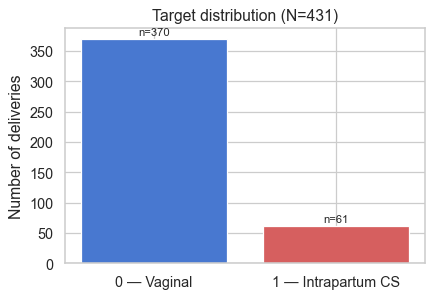

In [9]:
# Historical raw/pre-correction/exclusion counts below are read from the
# machine-generated preprocessing audit log (not hand-maintained literals),
# so they cannot silently drift out of sync with the actual pipeline run that
# produced DATA_PATH: outputs/preprocessing/audit/preprocessing_audit_log.md,
# "## Batch 2 -- Cohort definition, trial-of-labor correction, and target
# construction" section. That file is regenerated by run_preprocessing.py on
# every run and its header records the exact git commit / input-file SHA-256
# for the run it describes.
#
# One figure is not present there as an explicit number: the placenta
# accreta/previa exclusion (Decision 32) is a protected small cell (n<5),
# suppressed by the audit log's own small-cell privacy rule and never
# rendered as a literal in this notebook's source or output -- it is
# imported from analysis/preprocessing/src/preprocessing_config.py (a plain
# config module, never itself displayed here), the single authoritative,
# non-rendered location for this cited count, cited to
# docs/clinical_decisions/manual_decisions_log.md. It is cross-checked below
# via arithmetic consistency against the parsed audit-log figures (a break
# in either source will raise, rather than silently mismatch), but is never
# printed on its own.
_PLACENTA_DECISION32_EXCLUDED_ROWS = _preprocessing_config.DECISION_32_PLACENTA_EXCLUDED_ROWS

_audit_log_path = _root / "outputs/preprocessing/audit/preprocessing_audit_log.md"
if not _audit_log_path.is_file():
    raise FileNotFoundError(
        f"Preprocessing audit log not found: {_audit_log_path}. Section A4's cohort-derivation "
        "counts are sourced from this file and cannot be displayed without it."
    )
_audit_log_text = _audit_log_path.read_text(encoding="utf-8")
_batch2_match = re.search(r"## Batch 2 —.*?(?=\n## Batch 3|\Z)", _audit_log_text, re.DOTALL)
if not _batch2_match:
    raise ValueError(f"Could not locate the '## Batch 2' section in {_audit_log_path}.")
_batch2_text = _batch2_match.group(0)

def _extract_audit_int(label, text=_batch2_text):
    _m = re.search(rf"- {re.escape(label)}:\s*(\d+)", text)
    if not _m:
        raise ValueError(f"Could not find audit-log line {label!r} in the Batch 2 section of {_audit_log_path}.")
    return int(_m.group(1))

_raw_rows          = _extract_audit_int("Rows start")
_trial_corrections = _extract_audit_int("trial_of_labor corrections applied")
_elective_cs_excl  = _extract_audit_int("Elective CS excluded")
_no_trial_excl     = _extract_audit_int("Excluded no-trial-of-labor")
_d67_excl          = _extract_audit_int("Excluded suspected superficial-only endometriosis (Decision 67)")
_audit_final_cohort = _extract_audit_int("Final cohort")

# Self-consistency check: the audit log's own "Final cohort" figure for Batch
# 2 already has both the placenta_accreta/previa exclusion and the suspected
# superficial-only-endometriosis exclusion baked in (both are applied within
# the same batch, before the "Final cohort" line is written) -- so raw -
# elective_cs - no_trial - the cited placenta exclusion count - the
# superficial-only exclusion count must equal both the audit log's own
# "Final cohort" figure AND the loaded dataset's actual row count. This ties
# the one cited (non-audit-log-derivable) literal to the audit log's own
# arithmetic and to the live df, rather than letting any of the three drift
# silently.
_expected_final = (
    _raw_rows - _elective_cs_excl - _no_trial_excl
    - _PLACENTA_DECISION32_EXCLUDED_ROWS - _d67_excl
)
if _expected_final != _audit_final_cohort or _audit_final_cohort != len(df):
    raise ValueError(
        f"Cohort-count arithmetic mismatch: {_raw_rows} raw - {_elective_cs_excl} elective CS - "
        f"{_no_trial_excl} non-trial-of-labor - {_PLACENTA_DECISION32_EXCLUDED_ROWS} cited Decision "
        f"32 exclusion - {_d67_excl} Decision 67 exclusion = {_expected_final}, audit-log 'Final "
        f"cohort' = {_audit_final_cohort}, loaded dataset rows = {len(df)}. Investigate before "
        f"trusting Section A4's counts."
    )

print("Cohort definition")
print()
print("  The cohort is derived from the project's raw dataset through a sequence of")
print("  clinically motivated inclusion and exclusion steps applied during")
print("  preprocessing, summarized below.")
print()
_after_trial_stage = _raw_rows - _elective_cs_excl - _no_trial_excl
_after_placenta_stage = _after_trial_stage - _PLACENTA_DECISION32_EXCLUDED_ROWS
# Disclosure-safe design: the placenta accreta/previa exclusion count is a
# protected small cell (n<5). Withholding the placenta line alone is not
# sufficient -- the raw dataset size, the two trial-of-labor exclusion
# counts, and the post-placenta cohort size (447, needed below as the
# Decision-67 "before" anchor and therefore unavoidably shown later in this
# same cell) together over-determine the system: any THREE of {raw,
# elective_cs_excl, no_trial_excl, 447} exactly pin down the fourth. Since
# 447 recurs later in this cell (Decision-67's own before/after accounting)
# and cannot be removed from this cell's output entirely, and
# elective_cs_excl/no_trial_excl are legitimate, independently useful,
# large/safe clinical exclusion counts, the raw pre-filtering dataset size
# is the one value withheld from THIS printed flow (it is not otherwise
# printed anywhere in this notebook) -- this removes one of the four
# knowns, so the placenta count cannot be recovered by arithmetic on values
# printed anywhere in this cell.
print("  Trial-of-labor reconciliation: vaginal deliveries recorded without a documented trial of")
print(f"    labor were corrected to trial-of-labor status         : {_trial_corrections} rows")
print(f"  Excluded: elective cesarean section                : {_elective_cs_excl:>3} rows")
print(f"  Excluded: no documented trial of labor              : {_no_trial_excl:>3} rows")
print("  Excluded: placenta accreta / placenta previa        : <5 rows "
      "(individually suppressed, n<5, per project small-cell disclosure policy)")
print(f"  Excluded: suspected superficial-only endometriosis  : {_d67_excl:>3} rows")
print("  ─────────────────────────────────────────────────────────────────")
print(f"  Final cohort                                      : {len(df)} rows")
print()

# The suspected superficial-only-endometriosis exclusion is implemented in
# preprocessing (externally confirmed by Sheba's clinical team 2026-08-18 --
# Decision 67 is RESOLVED, not pending), in Batch 2's canonical early
# cohort-eligibility section (run_preprocessing.py, Steps 5-6, alongside the
# elective-CS/trial-of-labor/placenta_accreta-previa exclusions, before
# target_intrapartum_cs is created). df loaded above is already the
# POST-exclusion cohort (N=431). This block reports the full before/after
# reconciliation from the machine-generated Batch 2 audit log -- it does not
# recompute or re-derive the exclusion mask itself.
# The vaginal breakdown is not itself a small cell, but the CS breakdown IS
# (n<5). Share-safe: this project's own binary target means
# CS_excluded = N_excluded - Vaginal_excluded always -- so showing the
# aggregate N-level before/after/excluded triple (safe, large) AND the
# exact vaginal-level before/after/excluded triple (also safe on its own)
# side by side would let a reader recover the protected CS-level excluded
# count by simple subtraction, even without ever printing that count or a
# "CS excluded" line directly. The class-level (vaginal vs. CS) "before"/
# "excluded" breakdown of this exclusion is therefore not printed at all
# below -- only the safe,
# aggregate N-level before/after/excluded figures, plus the resulting
# (post-exclusion) target distribution, which is reported separately further
# below in this same cell using only "after" values (370/61), never paired
# with a "before" or "excluded" class-level count.
_d67_vag_excl = _extract_audit_int(
    "Excluded suspected superficial-only endometriosis (Decision 67), vaginal"
)
_d67_cs_excl = _d67_excl - _d67_vag_excl
_d67_n0_after = int((df[TARGET_COL] == 0).sum())
_d67_n1_after = int((df[TARGET_COL] == 1).sum())
_d67_n_after = len(df)
_d67_n_before = _d67_n_after + _d67_excl
_d67_n0_before = _d67_n0_after + _d67_vag_excl
_d67_n1_before = _d67_n1_after + _d67_cs_excl

# Fail-loud internal consistency checks only -- these values are used for
# assertions below, never printed as class-level before/excluded figures.
assert _d67_n_before == _d67_excl + _d67_n_after, "Decision 67: N_before = N_excluded + N_after failed"
assert _d67_n1_before == _d67_cs_excl + _d67_n1_after, "Decision 67: CS_before = CS_excluded + CS_after failed"
assert _d67_n0_before == _d67_vag_excl + _d67_n0_after, "Decision 67: Vaginal_before = Vaginal_excluded + Vaginal_after failed"
assert _d67_n_after == _d67_n1_after + _d67_n0_after, "Decision 67: N_after = CS_after + Vaginal_after failed"

print("  Suspected superficial-only endometriosis exclusion (Decision 67)")
print()
print("  This criterion was defined before the outcome (target_intrapartum_cs) was")
print("  constructed, so it could not have been shaped by delivery outcome. It")
print("  excludes deliveries where the only documented endometriosis finding was")
print("  superficial disease — with no peritoneal, deep, ovarian (endometrioma), or")
print("  cesarean-scar endometriosis, and no adenomyosis — and where the diagnosis")
print("  itself rested on clinical impression alone rather than a confirmed surgical")
print("  or imaging finding. Any record with documented adenomyosis is retained")
print("  regardless of this rule, and isolated surgical evidence without a")
print("  documented endometriotic lesion, excision, or pathology finding does not by")
print("  itself trigger exclusion.")
print()
print(f"    Cohort N (aggregate)     before: {_d67_n_before:>4}   |   after: {_d67_n_after:>4}   |   excluded: {_d67_excl:>3}")
print("    Vaginal-vs.-intrapartum-CS breakdown of this exclusion is not individually")
print("    reported: the intrapartum-CS component is a protected small cell (n<5); see")
print("    the final cohort target distribution below for the resulting (post-")
print("    exclusion) class counts only.")
print()
print("  Sensitivity cohorts using a broader or narrower version of this exclusion")
print("  criterion are reconstructable from this dataset via the")
print("  decision67_sensitivity_19group_excluded / _26group_excluded flag columns")
print("  (N=428 and N=421 respectively), without retaining the 16 excluded rows here.")
print()

if "trial_of_labor_corrected" in df.columns:
    _n_not1 = int((df["trial_of_labor_corrected"] != 1).sum())
    if _n_not1 == 0:
        print("  All retained rows meet the trial-of-labor inclusion criterion.")
    else:
        print(f"  Unexpected: {_n_not1} retained row(s) do not meet the trial-of-labor "
              "inclusion criterion.")

if TARGET_COL in df.columns:
    _vc  = df[TARGET_COL].value_counts().sort_index()
    _n0  = int(_vc.get(0, 0))
    _n1  = int(_vc.get(1, 0))
    _tot = len(df)
    _cs_pct = 100 * _n1 / _tot
    print(f"  Target: {TARGET_COL}")
    print(f"    0 = Vaginal delivery   : {_n0:>4}  ({100*_n0/_tot:.1f}%)")
    print(f"    1 = Intrapartum CS     : {_n1:>4}  ({_cs_pct:.1f}%)")
    print(f"    Class imbalance ratio  : {_n0/_n1:.1f}:1")
    print()
    print(f"  Note: the target is imbalanced ({_cs_pct:.1f}% intrapartum CS), which should")
    print("  be considered during model evaluation and threshold selection.")

    # Bar chart
    fig, ax = plt.subplots(figsize=(5, 3.5))
    _colors = [sns.color_palette("muted")[0], sns.color_palette("muted")[3]]
    ax.bar(["0 — Vaginal", "1 — Intrapartum CS"], [_n0, _n1], color=_colors)
    for _bar, _n in zip(ax.patches, [_n0, _n1]):
        ax.text(_bar.get_x() + _bar.get_width()/2, _bar.get_height() + 3,
                f"n={_n}", ha="center", va="bottom", fontsize=9)
    ax.set_ylabel("Number of deliveries")
    ax.set_title(f"Target distribution (N={_tot})")
    plt.tight_layout()
    plt.show()

**Key observations:**

In [10]:
_ko4_n0 = int((df[TARGET_COL] == 0).sum())
_ko4_n1 = int((df[TARGET_COL] == 1).sum())
print(f"- Cohort N={len(df)}; target is imbalanced ({_ko4_n0}:{_ko4_n1}, "
      f"ratio {_ko4_n0/_ko4_n1:.1f}:1) -- requires threshold selection and/or "
      f"class-imbalance handling during modeling, not during EDA.")
print(f"- All retained records satisfy the documented trial-of-labor inclusion "
      f"criterion (see above); the cohort definition is a preprocessing/cohort-control "
      f"decision, not something re-derived or altered by this notebook.")

- Cohort N=431; target is imbalanced (370:61, ratio 6.1:1) -- requires threshold selection and/or class-imbalance handling during modeling, not during EDA.
- All retained records satisfy the documented trial-of-labor inclusion criterion (see above); the cohort definition is a preprocessing/cohort-control decision, not something re-derived or altered by this notebook.


## Section A5 — Predictor Pool and Exclusion Rationale

This section defines the primary predictor pool and documents, group by group, why
every other variable is excluded or deferred from it: source, free-text, or audit-only
variables (`source_or_text_audit_exclude`); variables used to define or verify the
cohort (`cohort_control_exclude`); broad or clinically heterogeneous variables
(`clinically_nonspecific_exclude`); variables retained for audit, cohort-rule
derivation, or outcome-independent sensitivity analysis but excluded from every stage
because an alternative variable is the approved modeled representation of the same
information (`clinically_redundant_exclude`); variables that directly encode the
target or CS decision (`leakage_exclude`); intrapartum/postpartum/neonatal variables
(`intrapartum_or_post_delivery_exclude`); near-delivery variables excluded from Stage 1
but added in Stage 2 and remaining eligible in Stage 3 -- not a hard exclusion and not
intrapartum-only (`secondary_near_delivery_predictor`); confirmed-intrapartum-timing
variables excluded from the current pre-labor predictor pool only
(`intrapartum_predictor_exclude_from_prelabor_model`); timing not reliably determinable
from this dataset (`intrapartum_candidate_pending_timing_confirmation`); variables
awaiting source/coding clarification (`manual_review_pending`); timing/context not yet
confirmed (`awaiting_clinical_clarification`); and patient/delivery identifiers (`id`,
never used in any model). No variable classification is changed and no statistical
analysis is performed here — this section documents the existing classification and
re-asserts, as a safety check, that no excluded column appears in `predictor_allowed`.

**Predictor pool and exclusion accounting:**

In [11]:
# Full column accounting, derived dynamically from the canonical classification
# data (never hardcoded): total columns = Stage 1 + Stage 2 additions + Stage 3
# additions + everything else excluded/deferred from every prediction stage + target.
# These five groups are disjoint by construction (each column belongs to exactly one
# canonical classification label) and sum exactly to the total column count.
_a5_total_cols = len(df.columns)
_a5_n_stage1 = len(PREDICTOR_ALLOWED_COLS)
_a5_n_stage2 = len(SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS)
_a5_n_stage3 = len(INTRAPARTUM_PREDICTOR_EXCLUDE_COLS)
_a5_n_target = len(TARGET_COLS)
# "Excluded/deferred" here means excluded from ALL THREE prediction stages -- the
# 5 Stage-3 variables are NOT counted here, since they are eligible for Stage 3
# (see the companion Part 2 notebook), not hard exclusions.
_a5_n_excluded = _a5_total_cols - _a5_n_stage1 - _a5_n_stage2 - _a5_n_stage3 - _a5_n_target

print(f"{_a5_total_cols} total columns = {_a5_n_stage1} Stage 1 (pre-labor) "
      f"+ {_a5_n_stage2} Stage 2 additions (secondary near-delivery) "
      f"+ {_a5_n_stage3} Stage 3 additions (intrapartum) "
      f"+ {_a5_n_excluded} excluded/deferred from every stage "
      f"+ {_a5_n_target} target")
print()
print(f"- The {_a5_n_stage1} predictor_allowed variables form Stage 1 (pre-labor) of the "
      f"cumulative 3-stage predictor universe.")
print(f"- The {_a5_n_stage2} secondary_near_delivery_predictor variables are not hard "
      f"exclusions -- they are excluded from Stage 1 but added in Stage 2 (pre-labor + "
      f"near-delivery) and remain in Stage 3; see the companion Part 2 notebook for full "
      f"Stage 2/3 coverage.")
print(f"- The {_a5_n_stage3} intrapartum_predictor_exclude_from_prelabor_model variables "
      f"are also not hard exclusions -- they are excluded from Stage 1 and Stage 2 but "
      f"added in Stage 3 (pre-labor + near-delivery + intrapartum); see the "
      f"companion Part 2 notebook.")
print(f"- The {_a5_n_excluded} variables shown in the exclusion audit below are excluded "
      f"or deferred from every prediction stage (Stage 1, 2, and 3 alike) -- e.g. "
      f"leakage, post-delivery, source/audit-only, cohort-control, or pending-review "
      f"variables.")
print(f"- The target ({_a5_n_target} column) is not a predictor.")

156 total columns = 60 Stage 1 (pre-labor) + 6 Stage 2 additions (secondary near-delivery) + 5 Stage 3 additions (intrapartum) + 84 excluded/deferred from every stage + 1 target

- The 60 predictor_allowed variables form Stage 1 (pre-labor) of the cumulative 3-stage predictor universe.
- The 6 secondary_near_delivery_predictor variables are not hard exclusions -- they are excluded from Stage 1 but added in Stage 2 (pre-labor + near-delivery) and remain in Stage 3; see the companion Part 2 notebook for full Stage 2/3 coverage.
- The 5 intrapartum_predictor_exclude_from_prelabor_model variables are also not hard exclusions -- they are excluded from Stage 1 and Stage 2 but added in Stage 3 (pre-labor + near-delivery + intrapartum); see the companion Part 2 notebook.
- The 84 variables shown in the exclusion audit below are excluded or deferred from every prediction stage (Stage 1, 2, and 3 alike) -- e.g. leakage, post-delivery, source/audit-only, cohort-control, or pending-review variable

In [12]:
# Groups excluded from ALL THREE prediction stages (hard exclusions) -- these
# are the groups that make up _a5_n_excluded in the reconciliation above.
_EXCL_GROUPS = [
    ("source_or_text_audit_exclude",
     SOURCE_OR_TEXT_AUDIT_EXCLUDE_COLS,
     "Source, free-text, or raw-detail variables retained for "
     "audit/documentation only; excluded from direct modeling."),
    ("cohort_control_exclude",
     COHORT_CONTROL_EXCLUDE_COLS,
     "Variables used to define, filter, or verify the analytical cohort. "
     "Retained for audit and reproducibility but excluded from predictor "
     "modeling."),
    ("clinically_nonspecific_exclude",
     CLINICALLY_NONSPECIFIC_EXCLUDE_COLS,
     "Broad or clinically heterogeneous variables that lack sufficient "
     "specificity for meaningful predictor modeling. Retained for "
     "documentation and audit but excluded from predictor modeling "
     "following clinical expert guidance."),
    ("clinically_redundant_exclude",
     CLINICALLY_REDUNDANT_EXCLUDE_COLS,
     "Retained for audit, cohort-rule derivation, and outcome-independent "
     "sensitivity analyses, but excluded from every prediction stage because "
     "clinical experts selected a different variable as the modeled "
     "representation of the overlapping information."),
    ("leakage_exclude",
     LEAKAGE_EXCLUDE_COLS,
     "Variables that directly encode the target, cesarean decision, cesarean "
     "indication, or operative findings after the target decision."),
    ("intrapartum_or_post_delivery_exclude",
     INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS,
     "Variables measured or determined during labor, delivery, postpartum, or "
     "neonatal period; retained for outcomes/audit only."),
    ("intrapartum_candidate_pending_timing_confirmation",
     PENDING_TIMING_CONFIRMATION_COLS,
     "Timing relative to admission/labor cannot be reliably determined from "
     "this dataset; excluded from the primary pre-labor model on conservative "
     "timing-uncertainty grounds, not confirmed intrapartum."),
    ("manual_review_pending",
     MANUAL_REVIEW_PENDING_COLS,
     "Source or coding ambiguous (prior surgery vs current CS findings). "
     "Excluded until clinical/source review is complete; some variables may become "
     "candidates for a future model version after review."),
    ("awaiting_clinical_clarification",
     AWAITING_CLINICAL_CLARIFICATION_COLS,
     "Timing relative to the CS decision is unconfirmed. "
     "Pending clinical review before any use in modeling."),
    ("id",
     ID_COLS,
     "Patient/delivery identifiers. Must never enter any model."),
]

# Shown separately, NOT included in _EXCL_GROUPS / _total_excl: this group is
# a Stage 3 addition, not a hard exclusion from every stage --
# it is excluded from Stage 1 and Stage 2 only, and IS eligible in Stage 3.
_STAGE3_GROUP = (
    "intrapartum_predictor_exclude_from_prelabor_model",
    INTRAPARTUM_PREDICTOR_EXCLUDE_COLS,
    "Clinically confirmed intrapartum timing; excluded from "
    "Stage 1 and Stage 2, but added in Stage 3 (pre-labor + near-delivery + "
    "intrapartum) -- NOT a hard exclusion from every stage.",
)
print(f"STAGE 3 ADDITION (not a hard exclusion) -- "
      f"{_STAGE3_GROUP[0].upper()}  ({len(_STAGE3_GROUP[1])} columns)")
print(f"    Why: {_STAGE3_GROUP[2]}")
print(f"    Columns: {_STAGE3_GROUP[1]}")
print()

_total_excl = sum(len(g) for _, g, _ in _EXCL_GROUPS)
print(f"Hard-excluded variable groups (excluded from every prediction stage) — "
      f"{_total_excl} columns total")
print(f"(Of {len(df.columns)} total columns in the processed dataset; matches "
      f"_a5_n_excluded above)")
print()

for _grp_name, _grp_cols, _why in _EXCL_GROUPS:
    _present = [c for c in _grp_cols if c in df.columns]
    _absent  = [c for c in _grp_cols if c not in df.columns]
    print(f"  {_grp_name.upper()}  ({len(_grp_cols)} configured, {len(_present)} in file)")
    print(f"    Why: {_why}")
    print(f"    Columns: {_present[:6]}" +
          (f"  ... and {len(_present)-6} more" if len(_present) > 6 else ""))
    if _absent:
        print(f"    Not in file: {_absent}")
    print()

# Safety re-assert: no excluded column is in PREDICTOR_ALLOWED_COLS
_excl_set = set(
    c for _, cols, _ in _EXCL_GROUPS for c in cols
)
_overlap = sorted(set(PREDICTOR_ALLOWED_COLS) & _excl_set)
if _overlap:
    print(f"Note: {len(_overlap)} variable(s) unexpectedly appear in both the eligible "
          f"predictor set and an excluded category: {_overlap}")
else:
    print("No variables in the eligible predictor set overlap with categories excluded from prediction.")

print()
# Dynamic, not hardcoded: correctly reflects the current canonical registry
# state, whether or not any variables remain pending.
_a5_pending_total = (
    len(PENDING_TIMING_CONFIRMATION_COLS)
    + len(MANUAL_REVIEW_PENDING_COLS)
    + len(AWAITING_CLINICAL_CLARIFICATION_COLS)
)
if _a5_pending_total == 0:
    print("No variables currently remain in pending timing, manual-review, or "
          "clinical-clarification groups (all three groups are empty in the "
          "current canonical classification).")
else:
    print(f"Note: {_a5_pending_total} variable(s) remain in pending timing, "
          f"manual-review, or clinical-clarification groups; these are "
          f"deferred to clinical review before any modeling use.")
print("Current classifications reflect the canonical registry state at notebook build time.")

STAGE 3 ADDITION (not a hard exclusion) -- INTRAPARTUM_PREDICTOR_EXCLUDE_FROM_PRELABOR_MODEL  (5 columns)
    Why: Clinically confirmed intrapartum timing; excluded from Stage 1 and Stage 2, but added in Stage 3 (pre-labor + near-delivery + intrapartum) -- NOT a hard exclusion from every stage.
    Columns: ['meconium_stained_amniotic_fluid', 'gestational_age_at_delivery_days', 'induction_any_bin', 'indication_for_induction_clean', 'intrapartum_fever_or_chorioamnionitis_bin']

Hard-excluded variable groups (excluded from every prediction stage) — 84 columns total
(Of 156 total columns in the processed dataset; matches _a5_n_excluded above)

  SOURCE_OR_TEXT_AUDIT_EXCLUDE  (31 configured, 31 in file)
    Why: Source, free-text, or raw-detail variables retained for audit/documentation only; excluded from direct modeling.
    Columns: ['any_medical_problem_comment', 'regular_medications_comment', 'Fetus_Anamoly_comment', 'diagnosis_date', 'endometrioma_size', 'endometrioma_place']  ... an

**Key observations:**

In [13]:
print(f"- {_total_excl} of {len(df.columns)} columns are excluded or deferred from "
      f"every prediction stage, spread across {len(_EXCL_GROUPS)} rationale groups "
      f"(leakage, post-delivery timing, source/audit-only, pending review, etc.).")
_ko7_largest = max(_EXCL_GROUPS, key=lambda g: len(g[1]))
print(f"- Largest exclusion group: '{_ko7_largest[0]}' ({len(_ko7_largest[1])} columns).")
print("- " + (
    "No variables in the eligible predictor set overlap with categories excluded from prediction."
    if not _overlap else f"Overlap detected involving: {_overlap}."
))
print("- These are documentation/audit groupings only; no variable is dropped from the "
      "dataframe by this notebook.")

- 84 of 156 columns are excluded or deferred from every prediction stage, spread across 10 rationale groups (leakage, post-delivery timing, source/audit-only, pending review, etc.).
- Largest exclusion group: 'intrapartum_or_post_delivery_exclude' (37 columns).
- No variables in the eligible predictor set overlap with categories excluded from prediction.
- These are documentation/audit groupings only; no variable is dropped from the dataframe by this notebook.


## Supplementary Automated Profiling

Supplementary automated dataset profiling reports are available for internal
review but were not part of the primary analysis presented in this notebook
and are disabled by default. When enabled, they cover the full dataset and
the `predictor_allowed` variable set separately, and are configured to omit
row-level sample values. They are not a substitute for the manual EDA in
this notebook.

In [14]:
# Opt-in gate: both flags required before any library import, output
# directory creation, or file write. Disabled by default.
if not (RUN_AUTOMATED_PROFILING and SAVE_AGGREGATED_OUTPUTS):
    print("Supplementary automated profiling was not run for this analysis "
          "(disabled by default; not part of the primary analysis).")
else:
    try:
        from ydata_profiling import ProfileReport
        _YDATA_AVAILABLE = True
    except ImportError:
        _YDATA_AVAILABLE = False
        print("Automated profiling library not available; supplementary reports were not generated.")

    _PROFILING_OUT_DIR = (_root / "outputs/manual_review/eda_a_profiling") if _root else Path.cwd() / "eda_a_profiling"
    _PROFILING_OUT_DIR.mkdir(parents=True, exist_ok=True)

    # ── Scopes ──────────────────────────────────────────────────────────────
    # Column counts are derived from the current variable-type/classification
    # files loaded in Part 1, not hardcoded.
    assert df.shape[1] == len(classification_df), (
        f"Expected {len(classification_df)} columns in the processed dataset "
        f"(from the current classification file); found {df.shape[1]}."
    )
    assert len(PREDICTOR_ALLOWED_COLS) > 0, "predictor_allowed classification is empty."
    _pac_missing_from_df = [c for c in PREDICTOR_ALLOWED_COLS if c not in df.columns]
    assert not _pac_missing_from_df, (
        f"predictor_allowed column(s) not found in the dataset: {_pac_missing_from_df}"
    )
    print(f"  Initial predictor pool (predictor_allowed): {len(PREDICTOR_ALLOWED_COLS)} columns")
    _profile_predictor_cols = list(PREDICTOR_ALLOWED_COLS)

    # ── Dataset-profiling allowlist (distinct from model-predictor eligibility) ──
    # A column is admitted only if its type is aggregate-summarizable AND (for
    # structural-registry members) its applicable subgroup meets the
    # disclosure threshold. Default-deny: any future column type not already
    # recognized here is excluded rather than silently profiled in detail.
    _PROFILING_ALLOWED_TYPES = {"binary", "categorical", "ordinal", "continuous", "count"}
    _MIN_SUBGROUP_DISCLOSURE_N = 5  # project's established small-cell convention
    _confirmed_structural = structural_missingness_registry.CONFIRMED_STRUCTURAL
    _disallowed_rare_detail = sorted(
        v for v, meta in _confirmed_structural.items()
        if meta["expected_applicable_denominator"] < _MIN_SUBGROUP_DISCLOSURE_N
    )
    _PROFILING_ALLOWED_COLS = sorted(
        c for c in df.columns
        if VARIABLE_TYPE_MAP.get(c) in _PROFILING_ALLOWED_TYPES
        and c not in _disallowed_rare_detail
    )

    _profiling_status = []

    def _report_path(name):
        return _PROFILING_OUT_DIR / name

    def _status(tool, scope, path, ok, note=""):
        _profiling_status.append({"tool": tool, "scope": scope, "path": str(path), "success": ok, "note": note})

    # ── ydata-profiling ────────────────────────────────────────────────────
    if _YDATA_AVAILABLE:
        print("Generating supplementary profiling reports...")

        def _make_ydata_report(data, title, minimal):
            _r = ProfileReport(data, title=title, minimal=minimal, explorative=not minimal)
            # Suppresses the dataframe-level sample tab (head/tail/random rows)
            # and duplicate-row preview. This does NOT suppress a separate
            # per-variable widget that ydata-profiling renders for categorical
            # columns showing that column's raw first 1st-5th row values --
            # that widget is removed by post-generation redaction below.
            # vars.cat.n_obs/vars.bool.n_obs are deliberately left at their
            # library defaults: they do not control the row-level widget, only
            # a separate, legitimate compact top-categories preview table.
            _r.config.samples.head = 0
            _r.config.samples.tail = 0
            _r.config.samples.random = 0
            _r.config.duplicates.head = 0
            return _r

        # The per-variable row-sample widget has no dedicated suppression flag
        # in the installed ydata-profiling version; the only available flag
        # (`vars.cat.redact`) also blanks legitimate frequency-table category
        # labels, which is not acceptable. Instead, the widget's HTML fragment
        # is stripped post-generation and the result is verified before it is
        # treated as final (see _generate_ydata_report_safely below).
        import os as _os
        import re as _re
        _YDATA_SAMPLE_WIDGET_RE = _re.compile(
            r'<div class=col-sm-3><div class=table-responsive>'
            r'<p class="h4 item-header">Sample<table[^>]*>.*?</table></div></div>',
            _re.DOTALL,
        )
        # Literal ordinal row labels unique to this widget (no other
        # ydata-profiling template emits "1st row"/"2nd row"/etc.) -- used as
        # a fail-loud invariant check independent of the redaction pattern
        # itself, so a future ydata-profiling HTML structure change cannot
        # silently pass through an unredacted report.
        _ROW_ORDINAL_MARKERS = ("1st row", "2nd row", "3rd row", "4th row", "5th row")

        def _generate_ydata_report_safely(data, title, minimal, final_path):
            """Generate to a temporary file, redact, validate, then atomically
            replace final_path only if the report is verified free of
            row-level sample widgets. On any failure, the temporary file is
            removed and any previously validated final_path is left intact."""
            _tmp_path = final_path.with_name(final_path.stem + ".raw.tmp" + final_path.suffix)
            try:
                _make_ydata_report(data, title, minimal).to_file(_tmp_path)
                _html = _tmp_path.read_text(encoding="utf-8")
                _n_before = len(_YDATA_SAMPLE_WIDGET_RE.findall(_html))
                _redacted_html, _n_removed = _YDATA_SAMPLE_WIDGET_RE.subn("", _html)
                _n_remaining = sum(_redacted_html.count(_m) for _m in _ROW_ORDINAL_MARKERS)
                if _n_remaining:
                    raise RuntimeError(
                        f"YData privacy redaction FAILED for {final_path.name}: "
                        f"{_n_remaining} row-level ordinal-sample marker(s) (e.g. '1st row') "
                        f"remain after redaction ({_n_before} widget(s) detected, {_n_removed} "
                        f"removed by the known pattern). ydata-profiling's rendered HTML "
                        f"structure may have changed since this redaction pattern was verified "
                        f"-- this report requires manual privacy review and must not be treated "
                        f"as safe or copied to any review location."
                    )
                _tmp_path.write_text(_redacted_html, encoding="utf-8")
                _os.replace(_tmp_path, final_path)  # atomic on the same filesystem
                return _n_before, _n_removed
            except Exception:
                if _tmp_path.exists():
                    _tmp_path.unlink()
                raise

        try:
            # Allowlist-admitted columns only -- minimal=True: with up to 156
            # columns, full pairwise interactions/correlations would be
            # expensive and are not needed for a structural overview.
            _ydata_full_input = df[_PROFILING_ALLOWED_COLS].copy()
            _p = _report_path("EDA_A_YData_Full_Dataset.html")
            _n_before, _n_removed = _generate_ydata_report_safely(
                _ydata_full_input, "EDA A -- Broad Structural Profile (Automated Profiling, Supplementary) -- INTERNAL ONLY",
                minimal=True, final_path=_p,
            )
            _status("ydata-profiling", "full dataset", _p, True,
                    note=f"verified safe: {_n_before} row-sample widget(s) detected, "
                         f"{_n_removed} removed, 0 remaining")
        except Exception as _exc:
            _status("ydata-profiling", "full dataset", _report_path("EDA_A_YData_Full_Dataset.html"), False, str(_exc))

        try:
            # Predictor pool: small enough for the full (non-minimal) report.
            _p = _report_path("EDA_A_YData_Predictor_Pool.html")
            _n_before, _n_removed = _generate_ydata_report_safely(
                df[_profile_predictor_cols].copy(),
                "EDA A -- Restricted Predictor Profile: predictor_allowed (Automated Profiling, Supplementary) -- INTERNAL ONLY",
                minimal=False, final_path=_p,
            )
            _status("ydata-profiling", "predictor pool", _p, True,
                    note=f"verified safe: {_n_before} row-sample widget(s) detected, "
                         f"{_n_removed} removed, 0 remaining")
        except Exception as _exc:
            _status("ydata-profiling", "predictor pool", _report_path("EDA_A_YData_Predictor_Pool.html"), False, str(_exc))
    else:
        _status("ydata-profiling", "full dataset", _report_path("EDA_A_YData_Full_Dataset.html"), False, "library not installed")
        _status("ydata-profiling", "predictor pool", _report_path("EDA_A_YData_Predictor_Pool.html"), False, "library not installed")

    print("\nSupplementary automated profiling summary:")
    for _s in _profiling_status:
        _label = "generated" if _s["success"] else "not generated"
        print(f"  {_s['scope']}: {_label}")

Supplementary automated profiling was not run for this analysis (disabled by default; not part of the primary analysis).


## Section A6 — Univariate Descriptive Overview of Predictor Candidates

This section provides an unstratified, Table-1-style descriptive overview of all current
`predictor_allowed` variables, using each variable's statistical type (numeric,
binary, or categorical) to report the appropriate summary: numeric variables get N,
missingness, mean, SD, median, IQR, and min/max; binary variables get N, missingness, and
positive count/rate; categorical variables get N, missingness, and number of levels. No
association tests, between-group comparisons, or variable selection are performed here —
those are covered elsewhere in this notebook and its companion.

This section is intentionally scoped to Stage 1 (`predictor_allowed`) only, consistent
with Part 1's role as a basic, all-columns inventory. Full descriptive and statistical
coverage of Stage 2 (`predictor_allowed` + `secondary_near_delivery_predictor`) and
Stage 3 (Stage 2 + `intrapartum_predictor_exclude_from_prelabor_model`) — the cumulative
prediction stages — is provided in the companion Part 2 notebook,
which attaches each variable's earliest cumulative-stage entry point to every summary
table it builds.

In [15]:
def _infer_var_type(s, bin_thresh=3, cat_thresh=20):
    # Schema-first: consult the canonical variable_type_schema_minimal.csv
    # (VARIABLE_TYPE_MAP, loaded in Part 1) so numeric-coded categorical
    # variables (e.g. mode_of_conception) and small-range count variables
    # (e.g. G/P/LIVE_BIRTH/AB/CS) are typed correctly. Falls back to the
    # legacy dtype/unique-count heuristic only for a variable absent from
    # the schema (e.g. if the schema file could not be found).
    col = getattr(s, "name", None)
    if col in VARIABLE_TYPE_MAP:
        return SCHEMA_TO_EDA_TYPE.get(VARIABLE_TYPE_MAP[col], "categorical")
    s2 = s.dropna()
    if s2.empty:
        return "empty"
    if s2.nunique() <= bin_thresh and set(s2.unique()).issubset({0, 1, 0.0, 1.0}):
        return "binary"
    if pd.api.types.is_numeric_dtype(s) and s2.nunique() > cat_thresh:
        return "numeric"
    if s2.nunique() <= cat_thresh:
        return "categorical"
    return "numeric"

_numeric_rows, _binary_rows, _cat_rows = [], [], []

for _col in PREDICTOR_ALLOWED_COLS:
    if _col not in df.columns:
        continue
    _vtype = _infer_var_type(df[_col])
    _sub   = df[[_col]].dropna()
    _miss_n   = int(df[_col].isna().sum())
    _miss_pct = round(df[_col].isna().mean() * 100, 1)
    # Consult both structural-missingness registries (matching Section A3's
    # convention): APPLICABILITY_LINKED_COLS for the PENDING/unconfirmed tier
    # (no code-enforced gate), and SUBGROUP_APPLICABLE_COLS for the CONFIRMED
    # tier (code-enforced gate, e.g. cesarean-only or
    # endometriosis_surgery==1-only variables). Kept
    # as two SEPARATE booleans, matching Section A3's inv_df -- a pending
    # column must never be labeled "structural_nan" (confirmed) here.
    _structural_confirmed = _col in SUBGROUP_APPLICABLE_COLS
    _structural_pending = _col in APPLICABILITY_LINKED_COLS

    if _vtype == "numeric":
        _s = _sub[_col]
        _numeric_rows.append({
            "variable": _col, "N": len(_sub), "missing_%": _miss_pct,
            "structural_nan": _structural_confirmed,
            "potentially_structural_pending": _structural_pending,
            "mean": round(_s.mean(), 2), "SD": round(_s.std(), 2),
            "median": round(_s.median(), 2),
            "Q1": round(_s.quantile(0.25), 2), "Q3": round(_s.quantile(0.75), 2),
            "min": round(_s.min(), 2), "max": round(_s.max(), 2),
        })
    elif _vtype == "binary":
        _n_pos = int((_sub[_col] == 1).sum())
        _pos_pct = round(100 * _n_pos / len(_sub), 1) if len(_sub) else None
        _zero_variance = bool(_pos_pct is not None and _pos_pct in (0, 100))
        # True zero-variance (no positive cases, or -- symmetrically -- no
        # negative cases) is distinct from merely rare/near-zero-variance
        # (a nonzero but small minority category). Both are descriptive flags
        # only; eligibility is unchanged in Part 1 either way.
        # n_positive/positive_% here MUST stay raw
        # numeric -- this dict feeds the analytical _binary_rows/_ko6_binary_df
        # used for numeric comparisons below (zero-variance/rare-variance
        # filtering) and in Section A6's key-observations cell. Storing a
        # share-safe *string* here instead (as a prior revision did) made
        # `_ko6_binary_df["positive_%"] < 5` crash at runtime with TypeError
        # the moment any binary variable had 1-4 positive cases, since pandas
        # cannot compare a string to an int. Suppression is applied only to a
        # separate display copy, built just before printing, below.
        _binary_rows.append({
            "variable": _col, "N": len(_sub), "missing_%": _miss_pct,
            "structural_nan": _structural_confirmed,
            "potentially_structural_pending": _structural_pending,
            "n_positive": _n_pos,
            "positive_%": _pos_pct,
            "zero_variance": _zero_variance,
        })
    else:
        _cat_rows.append({
            "variable": _col, "N": len(_sub), "missing_%": _miss_pct,
            "structural_nan": _structural_confirmed,
            "potentially_structural_pending": _structural_pending,
            "n_levels": int(_sub[_col].nunique()),
        })

print("Note: these summaries are unstratified and are not association tests with the target.")
print()
if _numeric_rows:
    print("Numeric predictor candidates:")
    print(pd.DataFrame(_numeric_rows).to_string(index=False))
    print()
if _binary_rows:
    print("Binary predictor candidates:")
    # Share-safe display copy ONLY: n_positive can be small
    # (1-4) for a rare whole-cohort binary finding -- suppressed here for
    # display, on the same numerator-OR-complement n<5 rule used elsewhere.
    # The underlying _binary_rows list (and any DataFrame built from it
    # below, e.g. _ko6_binary_df) keeps raw numeric values for computation.
    _binary_df_display = pd.DataFrame(_binary_rows)
    # n_positive is shown alongside its own N in the
    # same row -- plain safe_count() only checks the numerator, so a large
    # unsuppressed n_positive (e.g. 443 of N=447) still discloses a small
    # complement (4) by subtraction. Uses the complement-aware helper.
    _binary_df_display["n_positive"] = [
        share_safe.safe_count_with_complement(int(_r["n_positive"]), int(_r["N"]), enabled=SHARE_SAFE_MODE)
        for _r in _binary_rows
    ]
    _binary_df_display["positive_%"] = [
        share_safe.safe_pct_with_denominator(int(_r["n_positive"]), int(_r["N"]), enabled=SHARE_SAFE_MODE)[0]
        for _r in _binary_rows
    ]
    print(_binary_df_display.to_string(index=False))
    print()
if _cat_rows:
    print("Categorical predictor candidates (multi-level):")
    print(pd.DataFrame(_cat_rows).to_string(index=False))

Note: these summaries are unstratified and are not association tests with the target.

Numeric predictor candidates:
               variable   N  missing_%  structural_nan  potentially_structural_pending    mean     SD  median      Q1      Q3     min     max
                    AGE 431      0.000           False                           False  31.590  4.810  32.000  29.000  35.000  18.000  46.000
                      G 431      0.000           False                           False   2.150  1.370   2.000   1.000   3.000   1.000  10.000
                      P 431      0.000           False                           False   0.680  0.920   0.000   0.000   1.000   0.000   5.000
             LIVE_BIRTH 431      0.000           False                           False   0.660  0.910   0.000   0.000   1.000   0.000   5.000
                     AB 431      0.000           False                           False   0.420  0.750   0.000   0.000   1.000   0.000   4.000
                     CS 431    

**Key observations:**

In [16]:
# _binary_rows holds raw numeric n_positive/positive_%
# (see the SA6_TABLE1 comment above); safe to compare numerically below.
_ko6_binary_df = pd.DataFrame(_binary_rows)
print(f"- {len(_numeric_rows)} numeric, {len(_binary_rows)} binary, and {len(_cat_rows)} "
      f"multi-level categorical predictor candidates in the current predictor_allowed pool.")
if len(_ko6_binary_df):
    _ko6_zerovar = _ko6_binary_df.loc[_ko6_binary_df["zero_variance"], "variable"].tolist()
    _ko6_rare = _ko6_binary_df.loc[
        ~_ko6_binary_df["zero_variance"] &
        ((_ko6_binary_df["positive_%"] < 5) | (_ko6_binary_df["positive_%"] > 95)), "variable"
    ].tolist()
    if _ko6_zerovar:
        print(f"- Zero-variance binary predictor(s) (no positive cases observed in this "
              f"cohort): {_ko6_zerovar}. These remain in the {len(PREDICTOR_ALLOWED_COLS)}-variable "
              f"predictor_allowed pool in Part 1; final analytical handling occurs in Part 2.")
    if _ko6_rare:
        print(f"- Rare/near-zero-variance binary variable(s) (<5% or >95% positive, but "
              f"not zero-variance): {_ko6_rare} -- flag for near-zero-variance "
              f"consideration during Feature Selection; not modified here.")
    _ko6_struct_bin = _ko6_binary_df.loc[_ko6_binary_df["structural_nan"], "variable"].tolist()
    if _ko6_struct_bin:
        print(f"- {len(_ko6_struct_bin)} binary predictor(s) carry a CONFIRMED structural_nan "
              f"flag (code-enforced subgroup gate; missingness is by clinical design outside "
              f"an applicable subgroup, not a data-quality gap; see A7 for the full subgroup "
              f"breakdown): {_ko6_struct_bin}")
    _ko6_pending_bin = _ko6_binary_df.loc[
        _ko6_binary_df["potentially_structural_pending"], "variable"
    ].tolist()
    if _ko6_pending_bin:
        print(f"- {len(_ko6_pending_bin)} binary predictor(s) are POTENTIALLY structural but "
              f"PENDING confirmation (no code-enforced gate, not exempted from missingness "
              f"review): {_ko6_pending_bin}")
print("- These summaries are unstratified descriptives; between-group (vaginal vs. "
      "intrapartum CS) comparisons with formal tests are performed in the companion "
      "predictor-readiness notebook.")

- 10 numeric, 44 binary, and 6 multi-level categorical predictor candidates in the current predictor_allowed pool.
- Zero-variance binary predictor(s) (no positive cases observed in this cohort): ['alcohol', 'HELLP', 'eclampsia', 'IUFD']. These remain in the 60-variable predictor_allowed pool in Part 1; final analytical handling occurs in Part 2.
- Rare/near-zero-variance binary variable(s) (<5% or >95% positive, but not zero-variance): ['EUP', 'S_P_CS', 'VBAC', 'cs_scar_endometriosis', 'bladder_lesion_resected', 'clexane_during_pregnancy', 'pregnancy_related_hypertensive_disorder', 'PIH', 'mild_PET', 'severe_PET', 'any_PET', 'SIPET', 'IUGR', 'polyhydramnios', 'magnesium', 'endo_resection_no_resection', 'endo_resection_epiploica', 'endo_resection_uterus', 'endo_resection_appendix'] -- flag for near-zero-variance consideration during Feature Selection; not modified here.
- 11 binary predictor(s) carry a CONFIRMED structural_nan flag (code-enforced subgroup gate; missingness is by clinic

## Section A7 — Dataset Missingness Overview

This section documents missing values across all dataset columns: a per-column
missingness summary grouped by classification, a row-level summary of how many delivery
records have ≥1 / ≥5 / ≥10 missing values, a subgroup applicability report, and a missingness
heatmap for visual pattern detection. Structural NaN variables — whose missingness is by
clinical design rather than a data-quality issue — are flagged separately throughout (see
the methodology note below).

**Methodology note — structural vs. in-subgroup missingness:** structural missingness
refers to values that are not applicable *outside* the relevant subgroup (e.g.
`endometrioma_size_clean` is NaN for every patient without an endometrioma, by design).
Missing values *within* the applicable subgroup remain genuine missingness and are
reported and evaluated separately below — a structural-NaN flag does not mean every
missing value for that column is structural.

In [17]:
# EDA A boundary: missingness is reported only.
# No rows or columns are removed, no imputation, no missing indicator columns.
# Structural vs. true missingness is separated below via the canonical
# SUBGROUP_ACCOUNTING mapping (built once in Section A3, Part 1).

# Missingness summary by group
_miss_summary = (
    inv_df.groupby("group")
    .agg(
        n_columns        = ("column", "count"),
        n_complete       = ("missing_%", lambda x: (x == 0).sum()),
        n_partial        = ("missing_%", lambda x: ((x > 0) & (x < 70)).sum()),
        n_high_miss      = ("missing_%", lambda x: (x >= 70).sum()),
        mean_missing_pct = ("missing_%", "mean"),
    )
    .round(1)
)
print("Missingness summary by group:")
print(_miss_summary.to_string())
print()
print("Note: this table is descriptive only. Missingness bins (n_partial, n_high_miss "
      ">=70%) are not used for exclusion or feature selection. Structural NaN (values "
      "not applicable outside a subgroup, e.g. endometrioma-only fields) can inflate a "
      "group's raw missing% relative to its in-subgroup missingness -- see the "
      "methodology note above.")
print()

# Row-level missingness summary
_row_miss = df.isna().sum(axis=1)
_r1 = int((_row_miss >= 1).sum())
_r5 = int((_row_miss >= 5).sum())
_r10 = int((_row_miss >= 10).sum())
print(f"Row-level missingness (across all {len(df.columns)} columns):")
print(f"  Rows with >= 1  missing value : {_r1:>3}  ({100*_r1/len(df):.1f}%)")
print(f"  Rows with >= 5  missing values: {_r5:>3}  ({100*_r5/len(df):.1f}%)")
print(f"  Rows with >= 10 missing values: {_r10:>3}  ({100*_r10/len(df):.1f}%)")
print(f"  Note: computed across all {len(df.columns)} dataset columns -- structural, outcome, "
      "leakage/source, and excluded variables included, not only predictor_allowed "
      "columns. This does NOT mean every record has >=10 missing predictor values.")
print()

# Subgroup applicability report -- reports each
# SUBGROUP_APPLICABLE_COLS entry with its own subgroup denominator, never the
# full-cohort denominator, and never as ordinary missingness. Most entries
# (adhesions/surgical_site_infection/etc.) use the cesarean subgroup;
# age_at_neonatal_death uses the neonatal_death==1 subgroup instead -- the
# mask is looked up per entry by subgroup_label, not hardcoded to cesarean.
#
# Small-subgroup disclosure guard: when the applicable subgroup denominator
# is small enough that a value breakdown could reveal an individual row's raw
# value (e.g. age_at_neonatal_death, whose applicable subgroup is small in
# the current cohort), printing it would violate this notebook's own safety
# rule that outputs must be
# aggregate-only and must never expose patient-level rows. Reuses this
# project's existing sparse-cell convention (n < 5, the same threshold used
# for too_sparse/min_expected_cell elsewhere in the EDA workflow) rather than
# a bespoke cutoff. Applies generically to every SUBGROUP_APPLICABLE_COLS
# entry -- not specific to any one variable -- so any future entry with a
# small subgroup is protected automatically.
#
# The same threshold is also applied PER-CELL below: a large subgroup can
# still contain individual small cells --
# e.g. a rare category, or a continuous variable's raw value_counts(), which
# for a measurement like endometrioma_size_clean has many cells of frequency
# 1 (a near-patient-level disclosure). Reporting behavior is chosen from the
# canonical variable-type schema (VARIABLE_TYPE_MAP, Part 1), not inferred:
#   - continuous/count: aggregate descriptive statistics only (mean, SD,
#     median, Q1, Q3, IQR, min, max) -- never raw values or a frequency table.
#   - categorical/binary/ordinal: per-category counts, but any category below
#     the threshold is combined into a single suppressed bucket rather than
#     printed individually.
#   - any other/unknown type (e.g. free text): no value breakdown at all --
#     documented-count only.
_SG_MIN_DISCLOSURE_N = 5
# Reuses the canonical SUBGROUP_MASKS built once in Section A3 (Part 1) --
# not redefined here, so A3/A7/A9/A10 all use exactly the same masks.
_sg_rows = []
for _sg_col, _sg_meta in SUBGROUP_APPLICABLE_COLS.items():
    _sg_label_a5 = _sg_meta["subgroup_label"]
    _sg_mask_a5 = SUBGROUP_MASKS[_sg_label_a5]
    _n_sg_a5 = int(_sg_mask_a5.sum())
    # Validation (not reader-facing): a subgroup-applicable variable must be
    # structural NaN outside its clinically applicable subgroup, never an
    # ordinary non-null value.
    _sg_n_outside_non_null = int(df.loc[~_sg_mask_a5, _sg_col].notna().sum())
    assert _sg_n_outside_non_null == 0, (
        f"{_sg_col}: {_sg_n_outside_non_null} non-null value(s) found outside its "
        f"clinically applicable subgroup ({_sg_label_a5}); these are expected to be "
        f"structural NaN."
    )
    _sg_series_in = df.loc[_sg_mask_a5, _sg_col]
    _sg_documented_n = int(_sg_series_in.notna().sum())
    _sg_vtype = VARIABLE_TYPE_MAP.get(_sg_col, "unknown")
    if _n_sg_a5 < _SG_MIN_DISCLOSURE_N:
        _sg_dist_a5 = f"Not reported (subgroup n<{_SG_MIN_DISCLOSURE_N})"
    elif _sg_vtype in ("continuous", "count"):
        if _sg_documented_n < _SG_MIN_DISCLOSURE_N:
            _sg_dist_a5 = f"Not reported (documented n<{_SG_MIN_DISCLOSURE_N})"
        else:
            _sg_s = _sg_series_in.dropna()
            _sg_q1, _sg_q3 = _sg_s.quantile(0.25), _sg_s.quantile(0.75)
            _sg_dist_a5 = (
                f"mean={_sg_s.mean():.1f}, SD={_sg_s.std():.1f}, "
                f"median={_sg_s.median():.1f}, IQR=[{_sg_q1:.1f}, {_sg_q3:.1f}], "
                f"range=[{_sg_s.min():.1f}, {_sg_s.max():.1f}]"
            )
    elif _sg_vtype in ("categorical", "binary", "ordinal"):
        # share_safe.safe_combine_rare_levels() (not a naive "combine every
        # level below threshold into one bucket" -- see that helper's own
        # docstring) is required here rather than an ad hoc combine: when
        # only ONE level falls below the threshold, a naive combined-bucket
        # total IS that single level's exact count, so printing "1 category
        # combined, n=4" still directly discloses 4. The shared helper folds
        # smallest-first until the combined bucket is either empty or safely
        # >= threshold (or, pathologically, the whole per-level breakdown
        # must be suppressed).
        _sg_vc_full = _sg_series_in.value_counts(dropna=True)
        _sg_level_counts = {str(k): int(v) for k, v in _sg_vc_full.items()}
        _sg_visible, _sg_combined_n, _sg_combined_k = share_safe.safe_combine_rare_levels(
            _sg_level_counts, threshold=_SG_MIN_DISCLOSURE_N
        )
        if not _sg_visible and _sg_combined_n is not None and _sg_combined_n < _SG_MIN_DISCLOSURE_N:
            _sg_dist_a5 = f"Not reported (n<{_SG_MIN_DISCLOSURE_N} in every category, combined)"
        else:
            _sg_dist_parts = [f"{k}: {v}" for k, v in _sg_visible.items()]
            if _sg_combined_k:
                _sg_dist_parts.append(
                    share_safe.format_combined_levels_note(_sg_combined_k, _sg_combined_n)
                )
            _sg_dist_a5 = "; ".join(_sg_dist_parts) if _sg_dist_parts else f"Not reported (n<{_SG_MIN_DISCLOSURE_N} in every category)"
    else:
        _sg_dist_a5 = "Distribution not shown for this variable type"

    # Share-safe display of the table's own "Applicable N" / "Observed N" /
    # "Missing within subgroup" columns -- previously always printed as exact
    # integers regardless of size, even when the "Distribution" field for the
    # same row was already correctly suppressed (e.g. age_at_neonatal_death,
    # whose Applicable N is a protected small cell). safe_count() protects a
    # small total on its own;
    # safe_count_with_complement() additionally protects Observed N whenever
    # its complement (the missing count) would itself be a small cell -- a
    # large, "safe-looking" Observed N shown next to a safe Applicable N
    # still discloses a small missing count by subtraction otherwise.
    _sg_applicable_disp = share_safe.safe_count(
        _n_sg_a5, threshold=_SG_MIN_DISCLOSURE_N, enabled=SHARE_SAFE_MODE
    )
    _sg_observed_disp = share_safe.safe_count_with_complement(
        _sg_documented_n, _n_sg_a5, threshold=_SG_MIN_DISCLOSURE_N, enabled=SHARE_SAFE_MODE
    )

    # Missing WITHIN the applicable subgroup -- genuine/unresolved missingness,
    # distinct from structural NaN outside the subgroup.
    _sg_acc = SUBGROUP_ACCOUNTING[_sg_col]
    if _sg_acc["fully_explained_by_structural"]:
        _sg_miss_str = f"0 of {_sg_applicable_disp}"
    else:
        _sg_miss_n = _sg_acc["missing_inside_applicable_N"]
        if isinstance(_sg_observed_disp, str) or isinstance(_sg_applicable_disp, str):
            # Observed N and/or Applicable N is itself protected in this row
            # -- the exact missing count cannot be safely shown alongside it
            # either, UNLESS it is a genuine zero (a zero missing count
            # discloses nothing about any individual record and stays
            # visible regardless of whether the totals themselves are
            # hidden, consistent with this project's "genuine zero stays
            # zero" convention).
            _sg_miss_disp = 0 if _sg_miss_n == 0 else share_safe.safe_count(
                _sg_miss_n, threshold=_SG_MIN_DISCLOSURE_N, enabled=SHARE_SAFE_MODE
            )
            _sg_miss_str = f"{_sg_miss_disp} of {_sg_applicable_disp}"
        else:
            _sg_pct_disp, _ = share_safe.safe_pct_with_denominator(
                _sg_miss_n, _n_sg_a5, threshold=_SG_MIN_DISCLOSURE_N, enabled=SHARE_SAFE_MODE
            )
            _sg_miss_str = f"{_sg_miss_n} of {_n_sg_a5} ({_sg_pct_disp}%)"

    _sg_rows.append({
        "Variable": _sg_col,
        "Applicable subgroup": _sg_label_a5,
        "Applicable N": _sg_applicable_disp,
        "Observed N": _sg_observed_disp,
        "Missing within subgroup": _sg_miss_str,
        "Distribution / summary": _sg_dist_a5,
    })

_sg_table = pd.DataFrame(_sg_rows)
print("Subgroup-applicable variables — missingness within their clinically applicable subgroup:")
print(_sg_table.to_string(index=False))
print()

# Full per-column missingness table sorted by group then by missing%
_miss_cols = inv_df.sort_values(
    ["group", "missing_%"], ascending=[True, False]
)[["column", "group", "missing_%", "structural_nan", "potentially_structural_pending"]].copy()

# Print only columns with any missingness
_with_miss = _miss_cols[_miss_cols["missing_%"] > 0]
print(f"Columns with any missing values: {len(_with_miss)} of {len(df.columns)}")
print()
print(_with_miss.to_string(index=False))

Missingness summary by group:
                                                   n_columns  n_complete  n_partial  n_high_miss  mean_missing_pct
group                                                                                                             
clinically_nonspecific_exclude                             2           2          0            0             0.000
clinically_redundant_exclude                               1           1          0            0             0.000
cohort_control_exclude                                     3           3          0            0             0.000
id                                                         2           1          1            0             1.000
intrapartum_or_post_delivery_exclude                      37          26          3            8            22.500
intrapartum_predictor_exclude_from_prelabor_model          5           4          1            0            11.200
leakage_exclude                                   

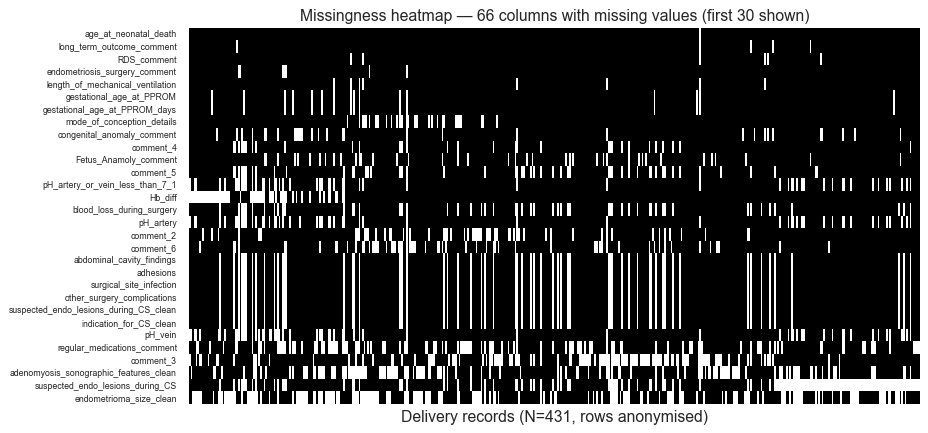

Black = missing  |  White = present  |  Sorted by missing%
Note: this heatmap is an internal descriptive diagnostic only. It is not used for row/column exclusion or imputation decisions.


In [18]:
# Missingness heatmap — all columns sorted by missing%
# x-axis = anonymised delivery-record rows, y-axis = variables with missing values
# No patient-level IDs on any axis.

_miss_sorted = inv_df.sort_values("missing_%", ascending=False)["column"].tolist()
_miss_matrix = df[_miss_sorted].isna().astype(int)  # 1=missing, 0=present

# Only show columns with any missing to keep the heatmap readable
_cols_with_miss = [c for c in _miss_sorted if df[c].isna().any()]
if len(_cols_with_miss) == 0:
    print("No missing values — heatmap skipped.")
else:
    _hm_data = df[_cols_with_miss].isna().astype(int)
    _n_show = min(30, len(_cols_with_miss))
    _hm_data = _hm_data.iloc[:, :_n_show]

    _fig_w = max(10, _n_show * 0.35)
    fig, ax = plt.subplots(figsize=(_fig_w, 5))
    sns.heatmap(
        _hm_data.T, cmap="Greys", cbar=False, ax=ax,
        yticklabels=_hm_data.columns.tolist(),
        xticklabels=False,  # no patient-level row labels
    )
    ax.set_xlabel(f"Delivery records (N={len(df)}, rows anonymised)")
    ax.set_ylabel("")
    ax.set_title(
        f"Missingness heatmap — {len(_cols_with_miss)} columns with missing values"
        + (f" (first {_n_show} shown)" if len(_cols_with_miss) > _n_show else "")
    )
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout()
    plt.show()
    print(f"Black = missing  |  White = present  |  Sorted by missing%")
    print("Note: this heatmap is an internal descriptive diagnostic only. "
          "It is not used for row/column exclusion or imputation decisions.")

**Key observations:**

In [19]:
# `structural_nan` is CONFIRMED-only (a code-enforced
# subgroup gate) -- `~inv_df["structural_nan"]` therefore now correctly
# INCLUDES potentially_structural_pending columns in the "requires review"
# high-missingness bucket below, rather than silently exempting them the way
# the prior combined flag did. A pending/unconfirmed column must never be
# given a free pass from missingness review.
_ko5_high_miss = inv_df[(inv_df["missing_%"] >= 70) & (~inv_df["structural_nan"])]
_ko5_struct = inv_df[inv_df["structural_nan"]]
_ko5_pending = inv_df[inv_df["potentially_structural_pending"]]
_ko5_pred_miss = inv_df[(inv_df["group"] == "predictor_allowed") & (inv_df["missing_%"] > 0)]

print(f"- {int((inv_df['missing_%'] == 0).sum())} of {len(inv_df)} columns are fully "
      f"complete; {len(_with_miss)} columns have at least some missingness.")
_ko5_partial_struct_n = sum(
    1 for c in SUBGROUP_ACCOUNTING if not SUBGROUP_ACCOUNTING[c]["fully_explained_by_structural"]
)
print(f"- {len(_ko5_struct)} column(s) have a CONFIRMED structural-missingness component "
      f"(code-enforced subgroup gate) outside a clinically applicable subgroup; "
      f"{_ko5_partial_struct_n} of these also retain genuine missingness within the "
      f"applicable subgroup (not fully explained by clinical applicability), as detailed "
      f"in the subgroup applicability report below.")
if len(_ko5_pending):
    print(f"- {len(_ko5_pending)} additional column(s) are POTENTIALLY structural but "
          f"PENDING confirmation (no code-enforced gate): "
          f"{_ko5_pending['column'].tolist()}. These are never treated as structural-by-"
          f"design and remain subject to ordinary missingness review.")
if len(_ko5_high_miss):
    print(f"- {len(_ko5_high_miss)} column(s) without a CONFIRMED structural-missingness "
          f"gate have >=70% missing "
          f"(e.g. {_ko5_high_miss.sort_values('missing_%', ascending=False)['column'].tolist()[:5]}"
          f"{'...' if len(_ko5_high_miss) > 5 else ''}) -- this set includes any "
          f"potentially-structural-pending column with high missingness, which is NOT "
          f"exempted from this review bucket. This is a descriptive, whole-dataset "
          f"finding across all {len(df.columns)} columns -- it includes audit/source/comment/outcome "
          f"and other non-modeling variables that are not candidates for imputation at "
          f"all. It does NOT imply that every such column requires missingness-mechanism "
          f"review; that assessment is only relevant for variables actually considered "
          f"for downstream analysis/modeling and for which a missing-data treatment "
          f"decision is needed.")
print(f"- {len(_ko5_pred_miss)} of {int((inv_df['group']=='predictor_allowed').sum())} "
      f"predictor_allowed variables have any missingness. Note: the row-level "
      f"missingness summary above is computed across all {len(df.columns)} dataset "
      f"columns, not restricted to predictor_allowed variables, so it does not represent "
      f"predictor-frame row-level missingness; that is evaluated separately in the "
      f"companion notebook's Section A2.7.")
print("- Observed missingness patterns above may suggest MCAR does not hold for some "
      "variables (e.g. concentration in specific columns or co-occurring gaps), but MNAR "
      "cannot be established from the observed dataset alone -- this requires "
      "consideration during the cleaning/modeling stage, not a conclusion drawn here.")

- 90 of 156 columns are fully complete; 66 columns have at least some missingness.
- 21 column(s) have a CONFIRMED structural-missingness component (code-enforced subgroup gate) outside a clinically applicable subgroup; 4 of these also retain genuine missingness within the applicable subgroup (not fully explained by clinical applicability), as detailed in the subgroup applicability report below.
- 3 additional column(s) are POTENTIALLY structural but PENDING confirmation (no code-enforced gate): ['adenomyosis_sonographic_features_clean', 'gestational_age_at_PPROM_days', 'indication_for_induction_clean']. These are never treated as structural-by-design and remain subject to ordinary missingness review.
- 20 column(s) without a CONFIRMED structural-missingness gate have >=70% missing (e.g. ['long_term_outcome_comment', 'RDS_comment', 'endometriosis_surgery_comment', 'length_of_mechanical_ventilation', 'gestational_age_at_PPROM_days']...) -- this set includes any potentially-structural-pe

## Section A8 — Initial IQR Outlier Screening

This section screens the numeric predictor candidates (the `continuous` and
`count` types from the variable-type schema, restricted to `predictor_allowed` variables)
for potential outliers using the IQR 1.5× rule, reporting per-variable bounds and the
count/rate of values outside them. This is a screening diagnostic only: no values are
removed or modified, no modeling eligibility is changed, and an IQR flag is not itself a
classification of a value as erroneous — statistical extremeness is not equivalent to
clinical impossibility. The main results table below lists only the predictors with at
least one flagged value (`n_flagged >= 1`); predictors with zero flags, and predictors
whose IQR is zero (for which standard 1.5×IQR flagging is not informative), are reported
separately so the full evaluated set remains visible. Descriptive outlier sensitivity
analysis, including outcome-rate comparison, is presented in A2 Section A2.11; those
target-aware comparisons are descriptive only and do not determine preprocessing or
feature selection.

In [20]:
# Outlier screening — IQR 1.5x, canonical numeric predictor_allowed columns only.
# SCREENING ONLY: no values removed, no modeling eligibility changed, no automatic
# classification as errors. The target is never consulted to decide whether an
# observation is flagged, and no feature selection is performed here.

# Numeric predictor set is read directly from the canonical variable-type schema
# (VARIABLE_TYPE_MAP, loaded in Part 1) -- the same source of truth already
# established in A3/A6 -- rather than re-inferred from storage dtype/cardinality.
# "continuous" and "count" are the schema's numeric types (see SCHEMA_TO_EDA_TYPE
# in Part 1, which maps both to the EDA "numeric" category).
_num_pred = [
    c for c in PREDICTOR_ALLOWED_COLS
    if c in df.columns
    and VARIABLE_TYPE_MAP.get(c) in ("continuous", "count")
]

_out_rows = []          # predictors with n_flagged >= 1 (the main results table)
_no_flag_rows = []      # predictors with IQR > 0 but zero flagged values
_iqr_zero_rows = []     # predictors with IQR == 0 -- not meaningfully screenable by
                        # the standard 1.5x-IQR rule; still evaluated and reported.
                        # IQR == 0 does NOT necessarily mean zero variance in the
                        # variable itself (e.g. a skewed distribution can have Q1==Q3
                        # while still having a wide observed range) and is not
                        # described as "constant" or "near-constant" here.
_insufficient_rows = [] # fewer than 4 non-missing values -- quartiles not reliable

for _col in _num_pred:
    _s = df[_col].dropna()
    if len(_s) < 4:
        _insufficient_rows.append(_col)
        continue
    _q1, _q3 = _s.quantile(0.25), _s.quantile(0.75)
    _iqr = _q3 - _q1
    # Matches A3/A6's convention: APPLICABILITY_LINKED_COLS is the PENDING/
    # unconfirmed tier (no code-enforced gate), SUBGROUP_APPLICABLE_COLS is
    # the CONFIRMED tier (code-enforced gate, e.g. endometrioma_size_clean).
    # kept as two SEPARATE booleans -- a pending
    # column must never be labeled "structural_nan" (confirmed) here.
    # Display/metadata only -- does not affect IQR bounds, flagged_%, or
    # which observations are flagged.
    _structural_confirmed = _col in SUBGROUP_APPLICABLE_COLS
    _structural_pending = _col in APPLICABILITY_LINKED_COLS
    if _iqr == 0:
        _iqr_zero_rows.append({
            "variable":       _col,
            "N_non_missing":  len(_s),
            "structural_nan": _structural_confirmed,
            "potentially_structural_pending": _structural_pending,
            "note":           "IQR-based outlier screening not informative because IQR = 0",
        })
        continue
    _lo, _hi = _q1 - 1.5 * _iqr, _q3 + 1.5 * _iqr
    _n_out = int(((df[_col] < _lo) | (df[_col] > _hi)).sum())
    # flagged_% denominator is N_non_missing (observed values actually eligible for
    # IQR screening), not the full cohort N -- missing values are excluded from the
    # variable-specific IQR calculation, not imputed, and must not be counted as if
    # they were screened-and-not-flagged.
    # n_flagged/flagged_% here MUST stay raw numeric --
    # this dict feeds _out_df, which is sorted by flagged_% both below and
    # again in the key-observations cell. Storing a share-safe *string* here
    # instead (as a prior revision did) made `.sort_values("flagged_%")`
    # crash at runtime with TypeError the moment any predictor had 1-4
    # flagged values, since Python/pandas cannot order a string against a
    # float. Suppression is applied only to a separate display copy, built
    # just before printing, below.
    _row = {
        "variable":       _col,
        "N_non_missing":  len(_s),
        "n_flagged":      _n_out,
        "flagged_%":      round(100 * _n_out / len(_s), 1),
        "iqr_lower":      round(_lo, 2),
        "iqr_upper":      round(_hi, 2),
        "actual_min":     round(_s.min(), 2),
        "actual_max":     round(_s.max(), 2),
        "structural_nan": _structural_confirmed,
        "potentially_structural_pending": _structural_pending,
    }
    (_out_rows if _n_out >= 1 else _no_flag_rows).append(_row)

print(f"Canonical numeric predictor candidates evaluated (continuous/count types, "
      f"predictor_allowed only): {len(_num_pred)}")
if _insufficient_rows:
    print(f"  {len(_insufficient_rows)} variable(s) have fewer than 4 non-missing "
          f"values and could not be screened: {_insufficient_rows}")
print()

if not _out_rows:
    print("No canonical numeric predictor has an IQR-flagged value (n_flagged >= 1) "
          "in the current cohort.")
else:
    _out_df = pd.DataFrame(_out_rows).sort_values("flagged_%", ascending=False)
    print(f"Variables with at least one IQR-flagged value (n_flagged >= 1): "
          f"{len(_out_df)} of {len(_num_pred)} evaluated.")
    print("This table contains ONLY predictors with n_flagged >= 1 -- it is not the "
          "full evaluated set (see the zero-flag and IQR=0 breakdowns below).")
    print()
    # Share-safe display copy ONLY: n_flagged can be small
    # (1-4); _out_df itself (sorted above, and reused in the key-observations
    # cell below) keeps raw numeric values throughout.
    _out_df_display = _out_df.copy()
    # n_flagged is shown alongside N_non_missing in
    # the same row -- plain safe_count() only checks the numerator, so a
    # large unsuppressed n_flagged still discloses a small complement by
    # subtraction. Uses the complement-aware helper.
    _out_df_display["n_flagged"] = [
        share_safe.safe_count_with_complement(int(_n), int(_N), enabled=SHARE_SAFE_MODE)
        for _n, _N in zip(_out_df["n_flagged"], _out_df["N_non_missing"])
    ]
    _out_df_display["flagged_%"] = [
        share_safe.safe_pct_with_denominator(int(_n), int(_N), enabled=SHARE_SAFE_MODE)[0]
        for _n, _N in zip(_out_df["n_flagged"], _out_df["N_non_missing"])
    ]
    print(_out_df_display.to_string(index=False))
    print()
    print("Flagged observations are carried forward for deeper analytical and, where")
    print("clinically relevant, clinical review. No observation is classified as")
    print("erroneous based on the IQR rule alone.")
    print("Descriptive outlier sensitivity analysis, including outcome-rate comparison,")
    print("is presented in A2 Section A2.11; those target-aware comparisons are")
    print("descriptive only and do not determine preprocessing or feature selection.")

print()
_no_flag_vars = [r["variable"] for r in _no_flag_rows]
print(f"Variables with IQR > 0 and zero flagged values ({len(_no_flag_rows)}): "
      f"{_no_flag_vars}")

if _iqr_zero_rows:
    print()
    print(f"Variables with IQR == 0 ({len(_iqr_zero_rows)}) -- standard 1.5x-IQR "
          f"flagging is not informative for these and none was performed, but they "
          f"remain evaluated canonical numeric predictors, not silently dropped:")
    print(pd.DataFrame(_iqr_zero_rows).to_string(index=False))

Canonical numeric predictor candidates evaluated (continuous/count types, predictor_allowed only): 10

Variables with at least one IQR-flagged value (n_flagged >= 1): 9 of 10 evaluated.
This table contains ONLY predictors with n_flagged >= 1 -- it is not the full evaluated set (see the zero-flag and IQR=0 breakdowns below).

               variable  N_non_missing       n_flagged                  flagged_%  iqr_lower  iqr_upper  actual_min  actual_max  structural_nan  potentially_structural_pending
             LIVE_BIRTH            431              19                      4.400     -1.500      2.500       0.000       5.000           False                           False
                      P            431              18                      4.200     -1.500      2.500       0.000       5.000           False                           False
             BMI_before            317              12                      3.800     10.640     34.870      14.200      47.020           False  

**Key observations:**

In [21]:
if "_out_df" in dir() and len(_out_df):
    # _out_df holds raw numeric flagged_%; sort is safe.
    _ko12_top = _out_df.sort_values("flagged_%", ascending=False).iloc[0]
    _ko12_top_pct_disp, _ = share_safe.safe_pct_with_denominator(
        int(_ko12_top["n_flagged"]), int(_ko12_top["N_non_missing"]), enabled=SHARE_SAFE_MODE
    )
    _ko12_top_pct_str = (
        f"{_ko12_top_pct_disp}%" if isinstance(_ko12_top_pct_disp, (int, float)) else str(_ko12_top_pct_disp)
    )
    print(f"- {len(_out_df)} of {len(_num_pred)} numeric predictor candidates have at "
          f"least one IQR-flagged value; highest flagged rate is "
          f"'{_ko12_top['variable']}' ({_ko12_top_pct_str}).")
    _ko12_struct = _out_df.loc[_out_df["structural_nan"], "variable"].tolist()
    if _ko12_struct:
        print(f"- Flagged variable(s) that are also CONFIRMED structural-NaN "
              f"(interpret bounds with the applicable subgroup in mind): {_ko12_struct}")
    _ko12_pending = _out_df.loc[_out_df["potentially_structural_pending"], "variable"].tolist()
    if _ko12_pending:
        print(f"- Flagged variable(s) that are POTENTIALLY structural but PENDING "
              f"confirmation (no code-enforced gate): {_ko12_pending}")
    print("- No observation is classified as erroneous based on the IQR rule alone, and "
          "none are removed or altered here. Descriptive outlier sensitivity analysis, "
          "including outcome-rate comparison, is presented in A2 Section A2.11; those "
          "target-aware comparisons are descriptive only and do not determine "
          "preprocessing or feature selection.")
else:
    print("- No numeric predictor candidate has an IQR-flagged value in the current cohort.")

- 9 of 10 numeric predictor candidates have at least one IQR-flagged value; highest flagged rate is 'LIVE_BIRTH' (4.4%).
- Flagged variable(s) that are also CONFIRMED structural-NaN (interpret bounds with the applicable subgroup in mind): ['endometrioma_size_clean']
- No observation is classified as erroneous based on the IQR rule alone, and none are removed or altered here. Descriptive outlier sensitivity analysis, including outcome-rate comparison, is presented in A2 Section A2.11; those target-aware comparisons are descriptive only and do not determine preprocessing or feature selection.


## Section A9 — Findings Summary

This section summarizes key data-quality and eligibility screening findings already
identified in earlier EDA A sections — high missingness among predictor candidates, IQR
outlier flags from Section A8, and predictor-pool exclusions for leakage or post-delivery
timing. These are screening signals and proposals only: this section does not modify
data, variable classifications, preprocessing, or modeling eligibility. Full per-variable
detail is retained internally for review rather than printed in full here.

In [22]:
# EDA A Findings Registry — screening findings only.
# All entries are proposals / screening signals. No decisions are made here.
# No classifications are changed. No preprocessing is modified.

_registry_rows = []

# ── High missingness (>30%) among predictor candidates ──────────────────
# A column-level structural_nan=True flag means the variable HAS a structural
# component -- it does not by itself mean the observed missingness is fully
# explained by clinical design. SUBGROUP_ACCOUNTING (Section A3, Part 1)
# distinguishes "fully explained" (0 missing within the applicable subgroup)
# from "structural NaN outside the subgroup, but genuine missingness also
# remains inside it" -- the latter must never be reported as "by clinical
# design; never impute blindly" as a blanket statement.
if "inv_df" in dir():
    for _, _r in inv_df[inv_df["group"] == "predictor_allowed"].iterrows():
        if _r["missing_%"] > 30:
            _col_name = _r["column"]
            _acc = SUBGROUP_ACCOUNTING.get(_col_name) if "SUBGROUP_ACCOUNTING" in dir() else None
            if _acc is not None and _acc["fully_explained_by_structural"]:
                _sev = "by_design"
                _step = (
                    "Structural NaN -- missingness is fully explained by clinical design "
                    "(0 missing within the applicable subgroup); never impute blindly."
                )
            elif _acc is not None:
                _sev = "review"
                _step = (
                    f"Structural missingness exists outside the clinically applicable "
                    f"subgroup; {_acc['missing_inside_applicable_N']} of "
                    f"{_acc['applicable_N']} applicable rows "
                    f"({_acc['missing_inside_applicable_%']}%) remain missing within "
                    f"the subgroup -- assess missingness mechanism for this "
                    f"within-subgroup portion in EDA A Part 2 before imputation."
                )
            else:
                # this branch is only reached when the
                # column has no SUBGROUP_ACCOUNTING entry, i.e. it is NOT in
                # SUBGROUP_APPLICABLE_COLS (not confirmed) -- so
                # _r["structural_nan"] (confirmed-only) is always False here
                # by construction. A potentially_structural_pending column
                # (no code-enforced gate) must NEVER be assigned "by_design"
                # severity -- that would exempt it from missingness review.
                # It gets its own "review" severity with an explicit note
                # instead.
                _pending = bool(_r.get("potentially_structural_pending", False))
                if _pending:
                    _sev = "review"
                    _step = (
                        "POTENTIALLY structural (empirical missingness pattern only, no "
                        "code-enforced gate) -- PENDING clinical/source confirmation. Not "
                        "exempted from missingness review and not eligible for NaN-to-zero "
                        "recoding until confirmed."
                    )
                else:
                    _sev = "review"
                    _step = (
                        "Assess observed missingness patterns and the plausibility of MCAR/MAR "
                        "when planning downstream handling in EDA A Part 2; MNAR cannot be "
                        "established from observed data alone."
                    )
            _registry_rows.append({
                "section":          "A7 — Missingness",
                "variable":         _col_name,
                "finding_type":     "high_missingness",
                "missing_%":        _r["missing_%"],
                "severity":         _sev,
                "suggested_next_step": _step,
            })

# ── Outlier-flagged numeric predictors ──────────────────────────────────
if "_out_df" in dir() and len(_out_df):
    for _, _r in _out_df.iterrows():
        # Share-safe: _r["n_flagged"] is raw here (_out_df keeps
        # raw numeric values); suppress only in this printed registry text.
        _n_flagged_disp = share_safe.safe_count(int(_r["n_flagged"]), enabled=SHARE_SAFE_MODE)
        _registry_rows.append({
            "section":          "A8 — Outlier screening",
            "variable":         _r["variable"],
            "finding_type":     "iqr_outlier_flag",
            "missing_%":        None,
            "severity":         "screening_flag",
            "suggested_next_step": (
                f"{_n_flagged_disp} value(s) outside IQR bounds "
                f"[{_r['iqr_lower']}, {_r['iqr_upper']}]. Carry forward for deeper "
                "analytical review and, where clinically relevant, clinical review. "
                "IQR flagging alone does not classify the observation as erroneous. "
                "See EDA A Part 2, Section A2.11 for deeper analysis."
            ),
        })

# ── Excluded groups (audit reference) ───────────────────────────────────
for _grp, _cols in [
    ("leakage_exclude",                   LEAKAGE_EXCLUDE_COLS),
    ("intrapartum_or_post_delivery_exclude", INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS),
    ("manual_review_pending",             MANUAL_REVIEW_PENDING_COLS),
    ("awaiting_clinical_clarification",   AWAITING_CLINICAL_CLARIFICATION_COLS),
]:
    for _c in _cols:
        if _c in df.columns:
            _registry_rows.append({
                "section":          "A5 — Exclusion documentation",
                "variable":         _c,
                "finding_type":     _grp,
                "missing_%":        None,
                "severity":         "excluded",
                "suggested_next_step": (
                    "Classification confirmed; excluded from modeling. See A5 for rationale."
                ),
            })

if not _registry_rows:
    print("No findings to report.")
else:
    # Retained in the notebook namespace at full per-variable detail for internal
    # review; the reader-facing output below is a concise summary, not the full table.
    eda_a_registry = pd.DataFrame(_registry_rows)
    _n_high_miss = int((eda_a_registry["finding_type"] == "high_missingness").sum())
    _n_outlier = int((eda_a_registry["finding_type"] == "iqr_outlier_flag").sum())
    _excluded_types = [
        "leakage_exclude", "intrapartum_or_post_delivery_exclude",
        "manual_review_pending", "awaiting_clinical_clarification",
    ]
    _n_excluded = int(eda_a_registry["finding_type"].isin(_excluded_types).sum())

    print("Summary of screening findings:")
    print()
    print(f"- Substantial missingness (>30%) among predictor_allowed candidates: "
          f"{_n_high_miss} variable(s). See Section A7 for the full missingness "
          f"breakdown and the structural-vs-genuine distinction.")
    print(f"- Flagged by descriptive IQR outlier screening: {_n_outlier} variable(s). "
          f"See Section A8; IQR flagging alone does not classify an observation as "
          f"erroneous.")
    print(f"- Excluded from the predictor pool (leakage, post-delivery timing, or "
          f"pending clinical review): {_n_excluded} variable(s), not part of the "
          f"predictor_allowed pool. See Section A5 for the full exclusion rationale.")
    print()
    print("These are screening findings and proposed next steps only; no variable is")
    print("removed or reclassified here, and no new exclusion or modeling decision is")
    print("introduced.")

Summary of screening findings:

- Substantial missingness (>30%) among predictor_allowed candidates: 15 variable(s). See Section A7 for the full missingness breakdown and the structural-vs-genuine distinction.
- Flagged by descriptive IQR outlier screening: 9 variable(s). See Section A8; IQR flagging alone does not classify an observation as erroneous.
- Excluded from the predictor pool (leakage, post-delivery timing, or pending clinical review): 45 variable(s), not part of the predictor_allowed pool. See Section A5 for the full exclusion rationale.

These are screening findings and proposed next steps only; no variable is
removed or reclassified here, and no new exclusion or modeling decision is
introduced.


## Section A10 — Part 1 Summary / Handoff

This section summarizes what is ready to carry forward into EDA A Part 2, what still
requires review, and what is permanently excluded from modeling.

In [23]:
print("=" * 70)
print("EDA A SUMMARY")
print("=" * 70)
print()
print(f"Cohort  : N={len(df)} (Vaginal={EXPECTED_N0}, Intrapartum CS={EXPECTED_N1}, "
      f"Ratio={EXPECTED_N0/EXPECTED_N1:.1f}:1)")
print(f"Dataset : {df.shape[0]} rows x {df.shape[1]} columns — all {df.shape[1]} columns have "
      f"an assigned classification")
print()

print("VARIABLE GROUPS:")
if "inv_df" in dir():
    for _g, _n in inv_df.groupby("group").size().sort_values(ascending=False).items():
        _col_unit = "column" if _n == 1 else "columns"
        print(f"  {_g:<45} {_n:>4} {_col_unit}")
print()

print("READY FOR EDA A PART 2:")
_ready = [c for c in PREDICTOR_ALLOWED_COLS if c in df.columns]
print(f"  predictor_allowed                : {len(_ready)} columns (predictor_allowed pool entering Part 2)")
if "_ko6_zerovar" in dir() and _ko6_zerovar:
    _n_effective = len(_ready) - len(_ko6_zerovar)
    print(f"    -- of these {len(_ready)}, {len(_ko6_zerovar)} ({sorted(_ko6_zerovar)}) were found in A6 to "
          f"have zero variance in this cohort (no positive cases observed). They remain part of the "
          f"canonical {len(_ready)}-variable predictor_allowed pool -- classification is unchanged and "
          f"they are NOT removed from it here -- but a variable with zero observed variance cannot "
          f"contribute to any variable-level inferential/modeling analysis (no contrast to estimate). "
          f"The effective candidate count actually usable for Part 2's inferential/modeling analysis "
          f"is therefore {len(_ready)} - {len(_ko6_zerovar)} = {_n_effective}.")
_snr = [c for c in SECONDARY_NEAR_DELIVERY_PREDICTOR_COLS if c in df.columns]
print(f"  secondary_near_delivery_predictor: {len(_snr)} columns (Stage 2 addition; eligible in "
      f"Stage 2 and Stage 3; full coverage in Part 2)")
_ipe = [c for c in INTRAPARTUM_PREDICTOR_EXCLUDE_COLS if c in df.columns]
print(f"  intrapartum_predictor_exclude_from_prelabor_model: {len(_ipe)} columns (Stage 3 addition; "
      f"excluded from Stage 1 and Stage 2, eligible only in Stage 3; NOT a hard "
      f"exclusion -- full coverage in Part 2)")
print()

print("REQUIRES REVIEW BEFORE MODELING:")
if "inv_df" in dir():
    # A variable with a structural component is only excluded from this review
    # list if its missingness is FULLY explained by clinical design (0 missing
    # within the applicable subgroup) -- see SUBGROUP_ACCOUNTING (Section A3,
    # Part 1). A column-level structural_nan=True flag alone is not sufficient:
    # some structural variables also carry genuine missingness inside their
    # applicable subgroup, which still requires review.
    #
    # The remaining candidates are split into two distinctly labeled groups so
    # this heading never implies that a subgroup-applicable predictor's full-
    # column missing_% (which is high mainly because it is not applicable
    # outside its subgroup) represents genuine within-subgroup missingness at
    # that same magnitude.
    _high_miss_candidates = inv_df[
        (inv_df["group"] == "predictor_allowed") & (inv_df["missing_%"] > 30)
    ]
    _hm_nonstructural, _hm_subgroup = [], []
    for _, _r in _high_miss_candidates.iterrows():
        _acc = SUBGROUP_ACCOUNTING.get(_r["column"]) if "SUBGROUP_ACCOUNTING" in dir() else None
        if _acc is not None and _acc["fully_explained_by_structural"]:
            continue  # fully explained by clinical design -- no review needed
        (_hm_subgroup if _acc is not None else _hm_nonstructural).append((_r, _acc))
    if _hm_nonstructural or _hm_subgroup:
        # Named "high-priority" (not "MISSINGNESS FINDINGS REQUIRING REVIEW") because
        # this list is restricted to predictor_allowed variables with >30% missing --
        # it is not the complete missingness picture (see A7 for the full per-column
        # missingness report across all dataset columns) and should not be read as such.
        print("  HIGH-PRIORITY MISSINGNESS FINDINGS:")
    if _hm_nonstructural:
        _hm_unit = "variable" if len(_hm_nonstructural) == 1 else "variables"
        print(f"    High non-structural missingness (full-column >30%, no CONFIRMED "
              f"applicable-subgroup structural component -- none of these are exempted "
              f"from review, including any potentially-structural-pending column below): "
              f"{len(_hm_nonstructural)} {_hm_unit}")
        for _r, _ in _hm_nonstructural:
            # flag a potentially-structural-pending column
            # explicitly here too, rather than lumping it in as flatly
            # "non-structural" -- it has a suspected (but unconfirmed) pattern,
            # not a confirmed absence of any structural explanation.
            _pending_note = (
                "  [POTENTIALLY STRUCTURAL -- PENDING CONFIRMATION]"
                if _r.get("potentially_structural_pending", False) else ""
            )
            print(f"      {_r['column']}: {_r['missing_%']}%{_pending_note}")
    if _hm_subgroup:
        _hm2_unit = "predictor" if len(_hm_subgroup) == 1 else "predictors"
        print(f"    Subgroup-applicable {_hm2_unit} with genuine within-subgroup "
              f"missingness (full-column missing_% is high mainly due to structural "
              f"non-applicability, not genuine missingness -- see A7 for the full "
              f"subgroup breakdown): {len(_hm_subgroup)} {_hm2_unit}")
        for _r, _acc in _hm_subgroup:
            print(f"      {_r['column']}: {_acc['missing_inside_applicable_N']} of "
                  f"{_acc['applicable_N']} applicable rows missing "
                  f"({_acc['missing_inside_applicable_%']}%) (full-column missing_%="
                  f"{_r['missing_%']}%)")
if "_out_df" in dir() and len(_out_df):
    _out_unit = "variable" if len(_out_df) == 1 else "variables"
    print(f"  IQR outlier-flagged predictors : {len(_out_df)} {_out_unit} (see A8)")
_pending = MANUAL_REVIEW_PENDING_COLS + AWAITING_CLINICAL_CLARIFICATION_COLS
_pending_in = [c for c in _pending if c in df.columns]
if _pending_in:
    _pending_unit = "variable" if len(_pending_in) == 1 else "variables"
    print(f"  Pending clinical review        : {len(_pending_in)} {_pending_unit} (see A5)")
print()

print("SELECTED HARD EXCLUSIONS (not exhaustive -- see A5 for the complete")
print("non-modeling breakdown, including source/audit, ID, cohort-control, and")
print("clinically nonspecific groups):")
_n_excl = len(LEAKAGE_EXCLUDE_COLS) + len(INTRAPARTUM_OR_POST_DELIVERY_EXCLUDE_COLS)
print(f"  leakage + intrapartum/post-delivery = {_n_excl} columns")
print()
print("NEXT STEP: 02b_eda_a_initial_predictor_readiness.ipynb")
print("  That notebook performs: predictor-vs-target association testing, deep missingness")
print("  analysis, numeric/categorical predictor-predictor correlation and association")
print("  screening, redundancy analysis, deep outlier review, and variable-readiness")
print("  scoring for predictor candidates.")
print("=" * 70)

EDA A SUMMARY

Cohort  : N=431 (Vaginal=370, Intrapartum CS=61, Ratio=6.1:1)
Dataset : 431 rows x 156 columns — all 156 columns have an assigned classification

VARIABLE GROUPS:
  predictor_allowed                               60 columns
  intrapartum_or_post_delivery_exclude            37 columns
  source_or_text_audit_exclude                    31 columns
  leakage_exclude                                  8 columns
  secondary_near_delivery_predictor                6 columns
  intrapartum_predictor_exclude_from_prelabor_model    5 columns
  cohort_control_exclude                           3 columns
  id                                               2 columns
  clinically_nonspecific_exclude                   2 columns
  clinically_redundant_exclude                     1 column
  target                                           1 column

READY FOR EDA A PART 2:
  predictor_allowed                : 60 columns (predictor_allowed pool entering Part 2)
    -- of these 60, 4 (['HELLP', 'I